# __BELLABEAT CASE STUDY__

### __INTRODUCTION__
Bellabeat is a high-tech manufacturer of health-focused products for women. Bellabeat designs wearables to capture data and deliver health insights primarily to the women demographic. The wearable tracks various health-related data like sleep, heart rate, and respiration. The collected data is processed and transformed into actionable health insights delivered through the Bellabeat app. To date, Bellabeat has provided information and actionable health insights that cover domains including (i) reproductive health, (ii) sleep, (iii) readiness, (iv) stress resistance, and (v) pregnancy.

### __BUSINESS TASK__
Urška Sršen, the Chief Creative Officer of Bellabeat, have requested for you to focus on Bellabeat's products and analyse smart device data to gain insight into how consumers are using their smart devices. She then wants you to select one Bellabeat product to apply these insights in our presentation. __These insights will help guide marketing strategy for the company.__ You will present your analyss to the Bellabeat executive team along with your high-level recommendation for Bellabeat's marketing strategy. These questions will guide your analyses:

- What are some trends in smart device usage?
- How could these trends apply to Bellabeat customers?
- How could these trends help influence Bellabeat marketing strategy?

### __STAKEHOLDERS__
- __Urška Sršen__: Bellabeat's co-founder and Chief Creative Officer
- __Sando Mur__: Mathematician and Bellabeat's co-founder, key member of the Bellabeat executive team
- __Marketing Analytics Team__: A team of analysts responsible for collecting, analysing, and reporting data that helps guide Bellabeat's marketing strategy.

### __DATA__
The [dataset][fitbit_dataset] used for this analysis is the FitBit Fitness Tracker Data and it was made available through Mobius on Kaggle (CC0: Public Domain). This Kaggle data set was created between 03.12.2016-05.12.2016 and contains personal fitness tracker from thirty fitbit users. Thirty eligible Fitbit users consented to the submission of personal tracker data, including minute-level output for physical activity, heart rate, and sleep monitoring. It includes information about daily activity, steps, and heart rate that can be used to explore users’ habits.

### __REFERENCES__
- Macarena Lacasa: [Capstone - Case Study Bellabeat][macarenalacasa_bellabeat]
- Joy Okwu: [Bellabeat Case Study With R][joyokwu_bellabeat]

[fitbit_dataset]: https://www.kaggle.com/datasets/arashnic/fitbit
[macarenalacasa_bellabeat]: https://www.kaggle.com/code/macarenalacasa/capstone-case-study-bellabeat/notebook
[joyokwu_bellabeat]: https://www.kaggle.com/code/joyokwu/bellabeat-case-study-with-r

### 1.1 Importing libraries

In [387]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import datetime
import operator
from matplotlib.colors import BoundaryNorm

In [172]:
plt.style.use('ggplot')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 10)

I have done some preliminary EDA and found that using the daily dataset would suffice in observing trends for smart device usage. So our analysis would only concentrate on the daily datasets

In [173]:
folder = './dataset/'
daily_filenames = [folder + i for i in os.listdir(folder) if 'daily' in i.lower() or 'day' in i.lower()]
# filenames = [folder + i for i in os.listdir(folder)]
for index, name in enumerate(daily_filenames):
    print(index, name)

0 ./dataset/dailyActivity_merged.csv
1 ./dataset/sleepDay_merged.csv
2 ./dataset/dailyCalories_merged.csv
3 ./dataset/dailySteps_merged.csv
4 ./dataset/dailyIntensities_merged.csv


### 1.2 Merging Datasets

In [349]:
# Importing the acitivity dataset
activity = pd.read_csv(daily_filenames[0], parse_dates=['ActivityDate'])

# Importing the sleep dataset
sleep = pd.read_csv(daily_filenames[1])
sleep['SleepDay'] = pd.to_datetime(sleep['SleepDay'], format='%m/%d/%Y %I:%M:%S %p')
sleep.rename(columns={'SleepDay':'ActivityDate'}, inplace=True)

# Importing the calories dataset
calories = pd.read_csv(daily_filenames[2], parse_dates=['ActivityDay'])
calories.rename(columns={'ActivityDay':'ActivityDate'}, inplace=True)

# Importing steps dataset
steps = pd.read_csv(daily_filenames[3], parse_dates=['ActivityDay'])
steps.rename(columns={'ActivityDay':'ActivityDate', 'StepTotal':'TotalSteps'}, inplace=True)

# Importing intensity dataset
intensity = pd.read_csv(daily_filenames[4], parse_dates=['ActivityDay'])
intensity.rename(columns={'ActivityDay':'ActivityDate'}, inplace=True)

print(activity.shape, sleep.shape, calories.shape, steps.shape, intensity.shape)

(940, 15) (413, 5) (940, 3) (940, 3) (940, 10)


Interestingly, the first (activity), third (calories), fourth (steps), and fifth (intensity) dataset has the same number of rows in their respective dataframes. The columns from the activity dataset also contains similar row names found in the latter three datasets. We should validate if the latter 3 datasets are subsets of the first dataset

In [350]:
# Check if the calories dataframe is a subset of the activity dataframe
calories_col = calories.columns

# Here, I am getting the index of the columns that appear in the calories dataframe so that I can slice the activity dataframe
calories_col_loc = [activity.columns.get_loc(i) for i in calories_col]
activity_part = activity.iloc[:, calories_col_loc]

# If all elements of the row are the same, the output for each row will return true. Next, I summed up all the boolean values.
# If the sum of the booleans equal to the number of records in the activity dataframe, then the calories dataframe is indeed a subset of the activity dataframe
print((calories == activity_part).all(axis=1).sum() == activity.shape[0])



# Check if the steps dataframe is a subset of the activity dataframe
steps_col = steps.columns
steps_col_loc = [activity.columns.get_loc(i) for i in steps_col]
activity_part = activity.iloc[:, steps_col_loc]
print((steps == activity_part).all(axis=1).sum() == activity.shape[0])

# Check if the intensity dataframe is a subset of the activity dataframe
intensity_col = intensity.columns
intensity_col_loc = [activity.columns.get_loc(i) for i in intensity_col]
activity_part = activity.iloc[:, intensity_col_loc]
print((intensity == activity_part).all(axis=1).sum() == activity.shape[0])

True
True
True


We found that the steps, intensity, and calories datasets are all subsets of the bigger activity dataframe, therefore it is sufficient to omit the former 3 datasets and concentrate on analysing the activity and sleep dataframes. We will also perform the additional step of merging the two dataframes

In [351]:
comb_df = activity.merge(sleep, how='outer', on=['Id', 'ActivityDate'])
comb_df

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed
0,1503960366,2016-04-12,13162,8.500000,8.500000,0.0,1.88,0.55,6.06,0.00,25,13,328,728,1985,1.0,327.0,346.0
1,1503960366,2016-04-13,10735,6.970000,6.970000,0.0,1.57,0.69,4.71,0.00,21,19,217,776,1797,2.0,384.0,407.0
2,1503960366,2016-04-14,10460,6.740000,6.740000,0.0,2.44,0.40,3.91,0.00,30,11,181,1218,1776,NaN,NaN,NaN
3,1503960366,2016-04-15,9762,6.280000,6.280000,0.0,2.14,1.26,2.83,0.00,29,34,209,726,1745,1.0,412.0,442.0
4,1503960366,2016-04-16,12669,8.160000,8.160000,0.0,2.71,0.41,5.04,0.00,36,10,221,773,1863,2.0,340.0,367.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
938,8877689391,2016-05-08,10686,8.110000,8.110000,0.0,1.08,0.20,6.80,0.00,17,4,245,1174,2847,NaN,NaN,NaN
939,8877689391,2016-05-09,20226,18.250000,18.250000,0.0,11.10,0.80,6.24,0.05,73,19,217,1131,3710,NaN,NaN,NaN
940,8877689391,2016-05-10,10733,8.150000,8.150000,0.0,1.35,0.46,6.28,0.00,18,11,224,1187,2832,NaN,NaN,NaN
941,8877689391,2016-05-11,21420,19.559999,19.559999,0.0,13.22,0.41,5.89,0.00,88,12,213,1127,3832,NaN,NaN,NaN


The dataset has been combined. We can now proceed with exploring the dataset with the `comb_df` dataframe

In [365]:
print(comb_df['Id'].nunique())
print(comb_df['ActivityDate'].nunique())

33
31


### 1.3 Checking for Duplicates
General Comments about the dataset:
- The [dataset][fitbit_dataset] claims that there are 30 participants over a two-month period, but what we have found is that there are <ins>__33__</ins> participants in this dataset over only a <ins>__one-month__</ins> period. The discrepancy of the description of the dataset compared to what is actually in the dataset the credibility of the dataset
- Further digging into other datasets needs to be performed to verify if the description of the dataset fits what is actually in the dataset

[fitbit_dataset]: https://www.kaggle.com/datasets/arashnic/fitbit

In [373]:
shape = comb_df.shape
duplicates = comb_df.duplicated().sum()
nulls = comb_df.isnull().sum().sum()
unique_id = comb_df['Id'].nunique()
unique_dates = comb_df['ActivityDate'].nunique()

print(f'Shape of the datafrae: rows: {shape[0]}, columns: {shape[1]}')
print(f'Number of duplicates in the dataframe: {duplicates}')
print(f'Number of nulls in the dataframe: {nulls}')
print(f'Unique participants in the dataframe: {unique_id}')
print(f'Unique dates in the dataframe: {unique_dates}')

Shape of the datafrae: rows: 943, columns: 18
Number of duplicates in the dataframe: 3
Number of nulls in the dataframe: 1590
Unique participants in the dataframe: 33
Unique dates in the dataframe: 31


We should expect an increase in the number of null values, since we had performed an outer join between the activity and sleep datasets. A prior analysis showed that there are 3 duplicates in the sleep dataset, which has been transferred into the combined dataset. Therefore, we should remove the duplicates to avoid instances of double coutning in our analysis

In [ ]:
df = comb_df.drop_duplicates().copy()

In [375]:
df.shape

(940, 18)

### 1.4 Exploratory Data Analysis

#### Steps

##### Q1: Do people use their smart device to track steps? If so, how many days out of 31 days do people use their wearables to track the number of steps walked?

<ins>Summary of Findings</ins>
- Everyone in the dataset use their smart devices to track their steps. The mean number of days tracked is 28 days, and the median is 31 days.
- If you own a wearable smart device like a Fitbit or an Apple Watch, we know that steps are recorded every day in the background without the need for activation. Therefore it is no surprise that everyone has at least one record of tracked steps

In [443]:
# Creating a pivot table to understand how many people have their steps tracked
steps = df.pivot_table(index=['Id'], columns=['ActivityDate'], values=['TotalSteps']).notna()

# The creation of a pivot table comes with unnecessary multi-index columns. In this example it is the 'TotalSteps' column in the zeroth level.
steps.columns = steps.columns.droplevel(0)

# We are now removing the pivot to create a dataframe suitable for plotting the distribution of days where people tracked their steps
steps_long = steps.reset_index().melt(id_vars='Id', var_name='day', value_name='steps_tracked')

# Group the data by participants and counting the number of days their steps are tracked.
days_tracked_steps = steps_long.groupby('Id')[['steps_tracked']].agg('sum')

In [442]:
days_tracked_steps.describe()

,steps_tracked
count,33.000000
mean,28.484848
std,5.657524
min,4.000000
25%,29.000000
50%,31.000000
75%,31.000000
max,31.000000


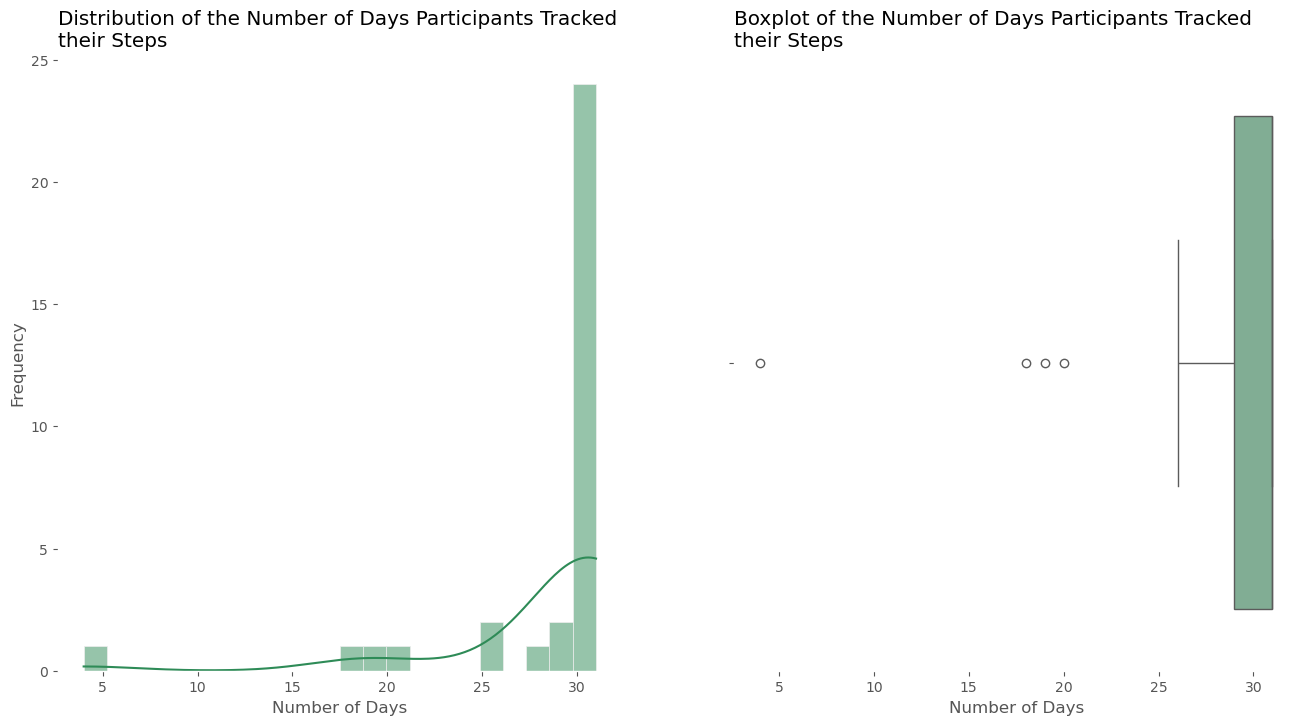

In [397]:
fig, ax = plt.subplots(1, 2, figsize=(16,8))
sns.histplot(data=days_tracked_steps, x='steps_tracked', color=sns.light_palette("seagreen")[-1], kde=True, ax=ax[0])
sns.boxplot(data=days_tracked_steps, x='steps_tracked', color=sns.light_palette("seagreen")[-3], ax=ax[1])

# Setting axes labels
ax[0].set_xlabel('Number of Days')
ax[0].set_ylabel('Frequency')
ax[0].set_title('Distribution of the Number of Days Participants Tracked \ntheir Steps', loc='left')
ax[1].set_xlabel('Number of Days')
ax[1].set_title('Boxplot of the Number of Days Participants Tracked \ntheir Steps', loc='left')
ax[0].set_facecolor('white')
ax[1].set_facecolor('white')

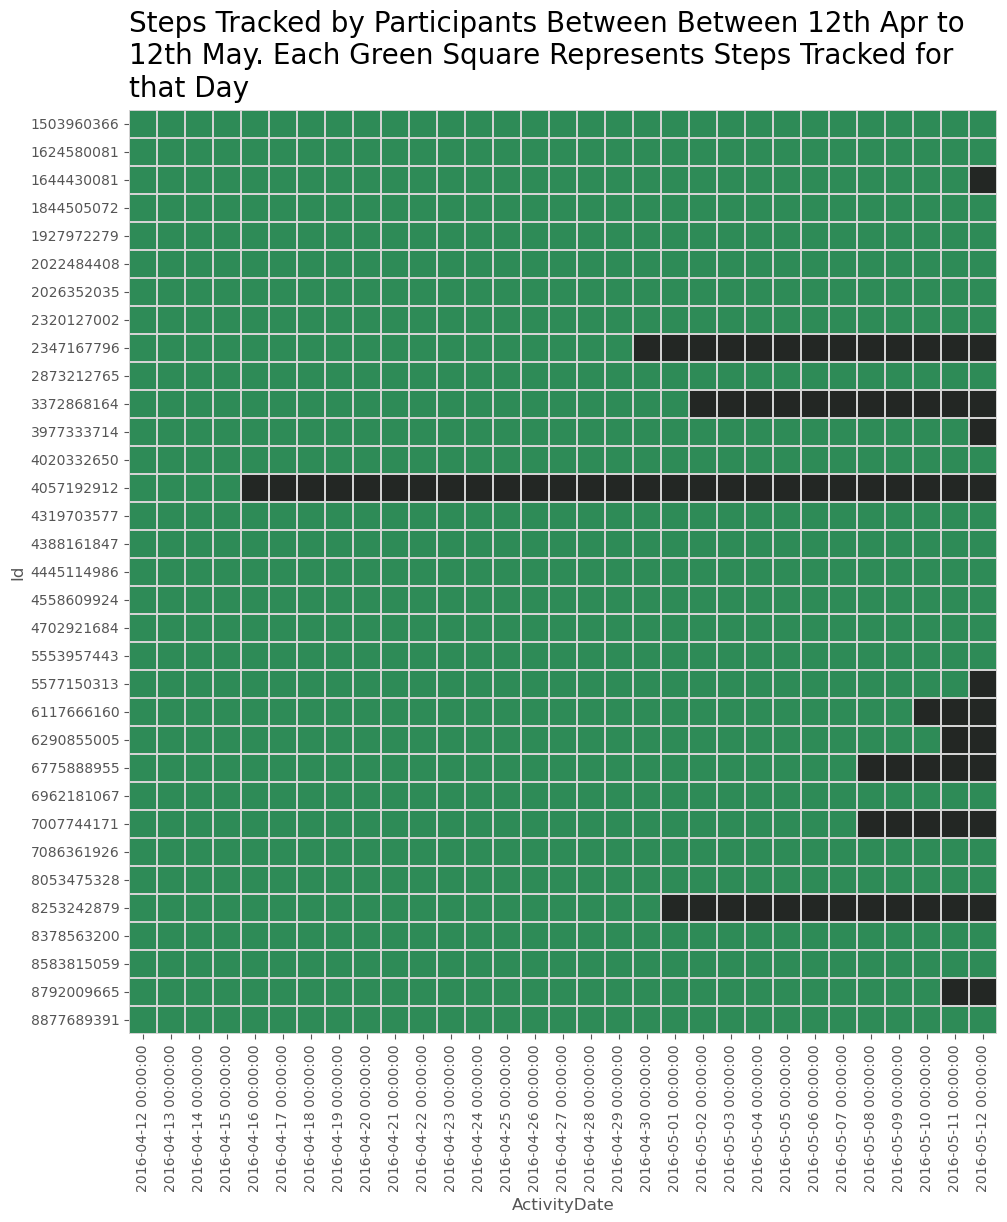

In [441]:
plt.subplots(figsize=(18,12))

# Using a green sequential palette to visualise sleep. The intense green i
seagreen_palette = sns.dark_palette("seagreen")

g = sns.heatmap(steps, square=True, 
                cmap=seagreen_palette, cbar=False,  # type: ignore
                linewidths=0.1, linecolor='lightgrey',
                xticklabels=steps.columns) # type: ignore

g.axes.set_title('Steps Tracked by Participants Between Between 12th Apr to \n12th May. Each Green Square Represents Steps Tracked for \nthat Day',  # type: ignore
                 loc='left', fontsize=20, pad=10)
g.axes.set_facecolor('white') # type: ignore

##### Q2: How many steps do participants take each day?

<ins>Summary of Findings</ins>
- Taking the mean over 31 days, participants took between 916 and 16,000 steps, the median was 7,200 steps.

In [473]:
# Creating a pivot table to understand how many people have their steps tracked
steps_q2 = df.pivot_table(index=['Id'], columns=['ActivityDate'], values=['TotalSteps']) # type: ignore

# The creation of a pivot table comes with unnecessary multi-index columns. In this example it is the 'TotalSteps' column in the zeroth level.
steps_q2.columns = steps_q2.columns.droplevel(0)

# We are now removing the pivot to create a dataframe suitable for plotting the distribution of days where people tracked their steps
steps_num = steps_q2.reset_index().melt(id_vars='Id', var_name='day', value_name='steps_tracked')

# Group the data by participants and counting the number of days their steps are tracked.
num_tracked_steps = steps_num.groupby('Id')[['steps_tracked']].agg('mean')

In [478]:
steps_num.describe()

,Id,steps_tracked
count,1.023000e+03,940.000000
mean,4.857201e+09,7637.910638
std,2.397779e+09,5087.150742
min,1.503960e+09,0.000000
25%,2.347168e+09,3789.750000
50%,4.445115e+09,7405.500000
75%,6.962181e+09,10727.000000
max,8.877689e+09,36019.000000


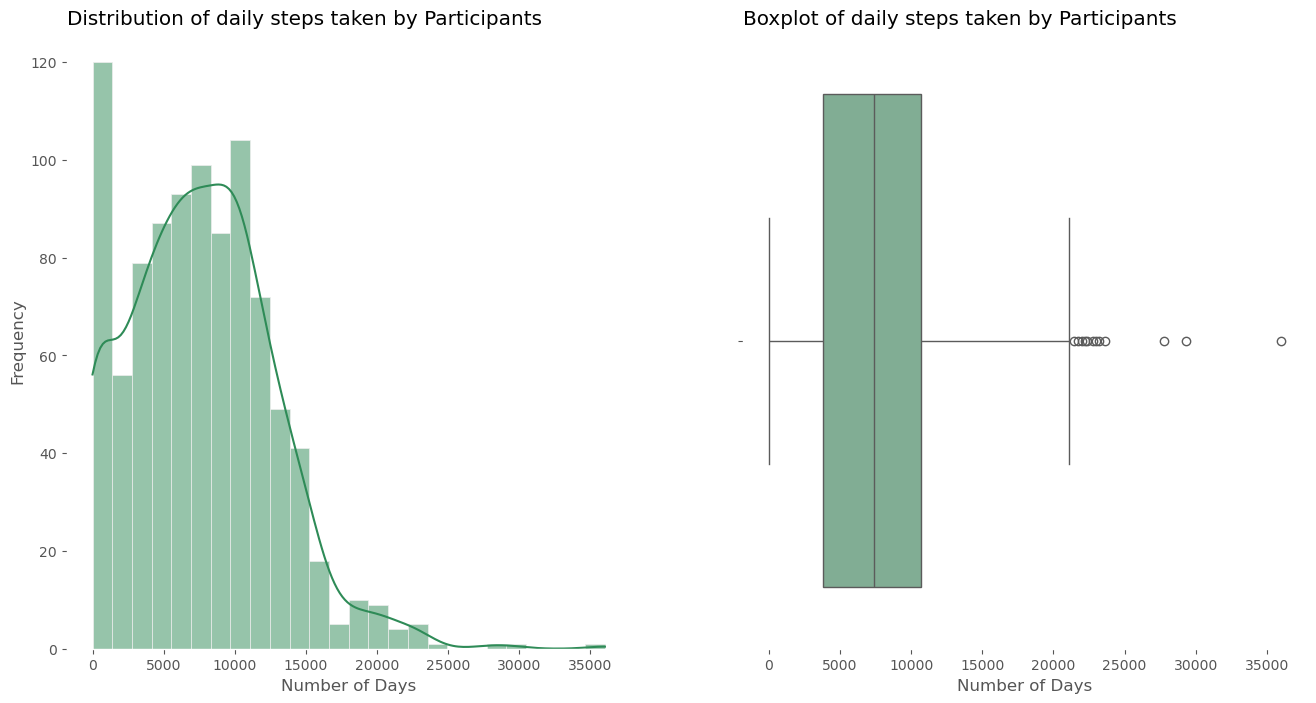

In [480]:
# Plotting participants' daily step count without regard for the identity of the participants. Each count is the number of steps for each day
fig, ax = plt.subplots(1, 2, figsize=(16,8))
sns.histplot(data=steps_num, x='steps_tracked', color=sns.light_palette("seagreen")[-1], kde=True, ax=ax[0])
sns.boxplot(data=steps_num, x='steps_tracked', color=sns.light_palette("seagreen")[-3], ax=ax[1])

# Setting axes labels
ax[0].set_xlabel('Number of Days')
ax[0].set_ylabel('Frequency')
ax[0].set_title('Distribution of daily steps taken by Participants', loc='left')
ax[1].set_xlabel('Number of Days')
ax[1].set_title('Boxplot of daily steps taken by Participants', loc='left')
ax[0].set_facecolor('white')
ax[1].set_facecolor('white')

In [449]:
num_tracked_steps.describe()

,steps_tracked
count,33.000000
mean,7519.272678
std,3576.340125
min,916.129032
25%,5566.870968
50%,7282.966667
75%,9519.666667
max,16040.032258


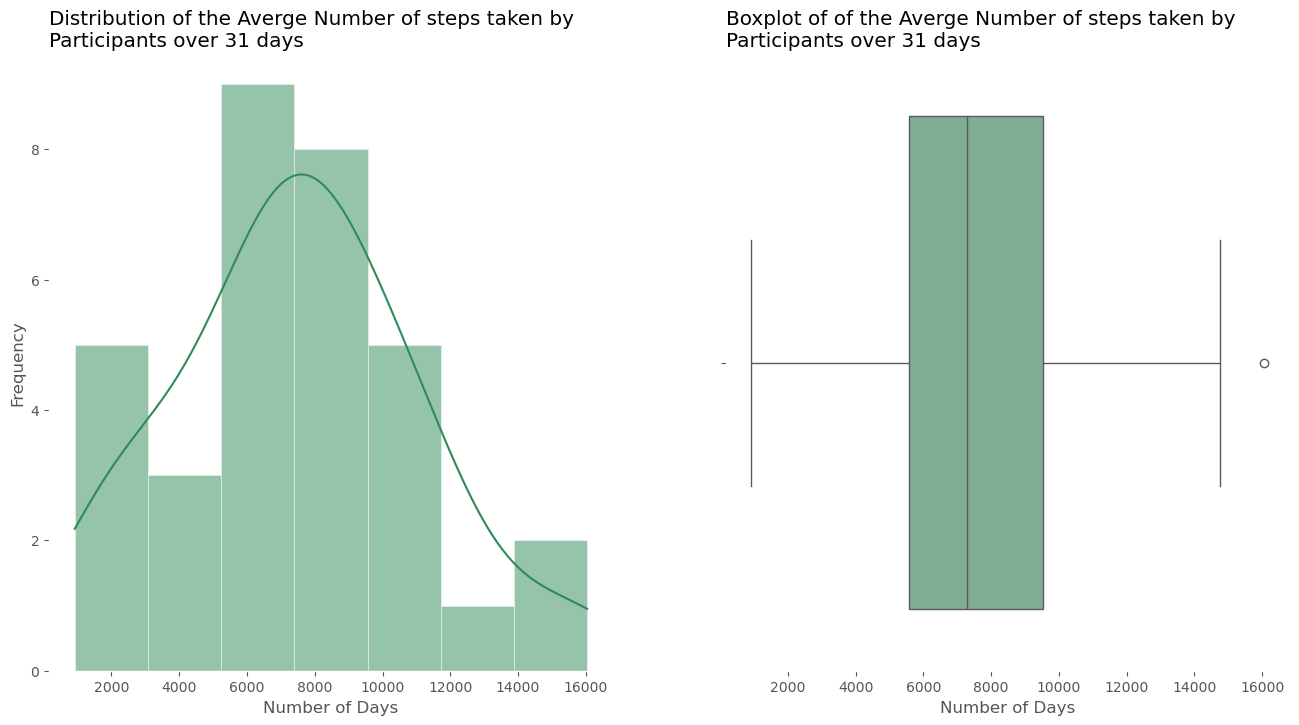

In [481]:
# Here, we took an average of participants daily step count over the 31 days. Each count is the participants mean steps over the 31-day period
fig, ax = plt.subplots(1, 2, figsize=(16,8))
sns.histplot(data=num_tracked_steps, x='steps_tracked', color=sns.light_palette("seagreen")[-1], kde=True, ax=ax[0])
sns.boxplot(data=num_tracked_steps, x='steps_tracked', color=sns.light_palette("seagreen")[-3], ax=ax[1])

# Setting axes labels
ax[0].set_xlabel('Number of Days')
ax[0].set_ylabel('Frequency')
ax[0].set_title('Distribution of the Averge Number of steps taken by \nParticipants over 31 days', loc='left')
ax[1].set_xlabel('Number of Days')
ax[1].set_title('Boxplot of of the Averge Number of steps taken by \nParticipants over 31 days', loc='left')
ax[0].set_facecolor('white')
ax[1].set_facecolor('white')

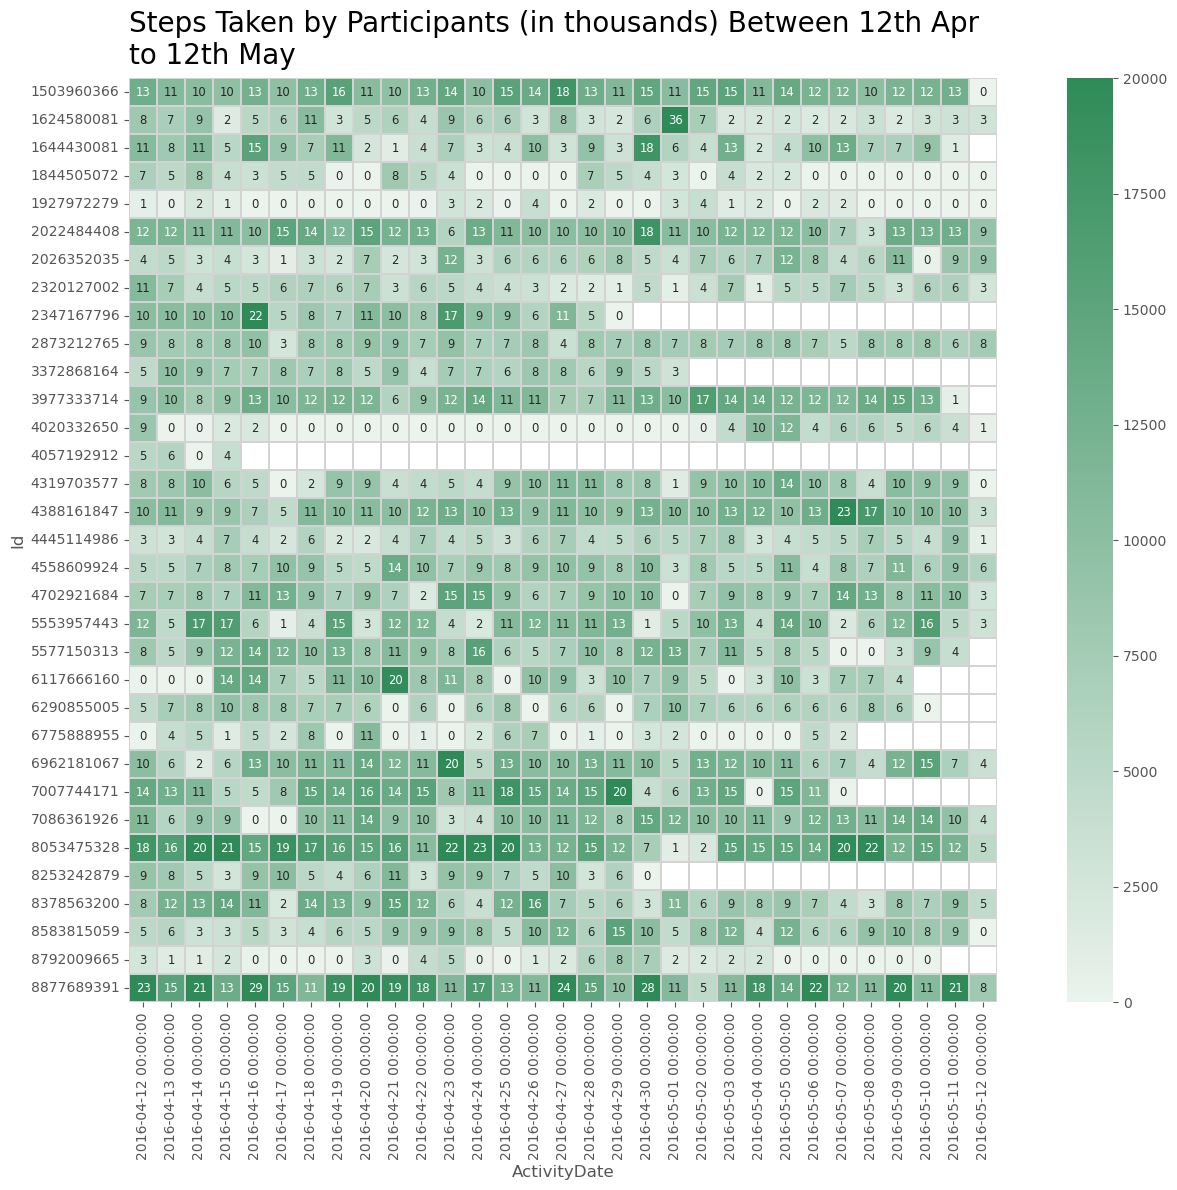

In [562]:
# Here, we plot a heat map showing all participants as rows, and all dates as columns. Each square represents a day and the number represents the steps taken for that day (in thousands)

plt.subplots(figsize=(18,12))

# Using a green sequential palette to visualise sleep. The intense green i
seagreen_palette = sns.light_palette("seagreen", as_cmap=True)

# Creating labels for the heatmap
labels = steps_q2.map(lambda x: f'{x/1000:.0f}')

g = sns.heatmap(steps_q2, square=True, 
                cmap=seagreen_palette, cbar=True,  # type: ignore
                vmin=0, vmax=20000,
                linewidths=0.1, linecolor='lightgrey',
                annot=labels, annot_kws={'size':'small', 'alpha':1}, fmt='',
                xticklabels=steps.columns) # type: ignore

g.axes.set_title('Steps Taken by Participants (in thousands) Between 12th Apr \nto 12th May',  # type: ignore
                 loc='left', fontsize=20, pad=10)
g.axes.set_facecolor('white') # type: ignore

#### Sleep

##### Q3: How many days out of 31 days do people track their sleep? Investigating the distribution of sleep records
<ins>Summary of Findings</ins>
- The distribution is bimodal, participants either religiously track their sleep or their do not. There are more people that do not track sleep than those who did. Since the distribution is bimodal, summary statistics might not be very applicable here
- Knowing this allows for the app to make recommendations that encourages people to track their sleep

In [488]:
# creating a dataframe counting the number of days each person logged their sleep in the month
num_of_tracked_sleep_days = df.groupby('Id')[['TotalSleepRecords']].agg('count')
# num_of_tracked_sleep_days

In [492]:
num_of_tracked_sleep_days.describe()

,TotalSleepRecords
count,33.000000
mean,12.424242
std,12.359284
min,0.000000
25%,0.000000
50%,5.000000
75%,26.000000
max,31.000000


Text(0.0, 1.0, 'Distribution of sleep records kept by participants \nover 31 days')

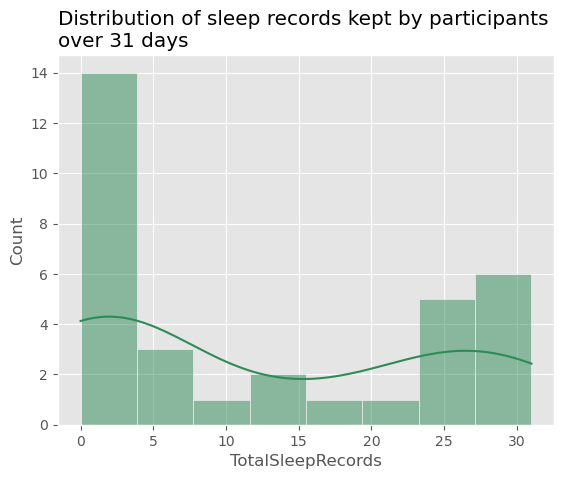

In [517]:
# Creating the histogram of 
g = sns.histplot(data=num_of_tracked_sleep_days, x='TotalSleepRecords', color=sns.light_palette("seagreen")[-1], kde=True, bins=8)
g.axes.set_title('Distribution of sleep records kept by participants \nover 31 days', loc='left') # type: ignore

##### Q4: How many hours do each person sleep per day in the 30-day window?

<ins>Summary of Findings</ins>
- This analysis is conducted for the 24 participants who recorded their sleep in their smart devices.
- The mean hours of sleep is 6.29 hours and the median is 6.59 hours. When median > mean, this meand that the distribution is right-skewed. 

In [530]:
# Creating a pivot table to visualise the number of hours each person sleeps per day in a heatmap. 
sleep_pivot = comb_df.pivot_table(index=['Id'], columns=['ActivityDate'], values=['TotalMinutesAsleep'], dropna=False) # type: ignore

# Creating a pivot table results in uncessary hierarchical columns. Using droplevel to remove unnecessary multi-columns
sleep_pivot.columns = sleep_pivot.columns.droplevel(0).date

# Total minutes asleep is recorded in minutes. Converting it into hours
sleep_pivot = sleep_pivot.divide(60)

sleep_pivot

,2016-04-12,2016-04-13,2016-04-14,2016-04-15,2016-04-16,2016-04-17,2016-04-18,2016-04-19,2016-04-20,2016-04-21,2016-04-22,2016-04-23,2016-04-24,2016-04-25,2016-04-26,2016-04-27,2016-04-28,2016-04-29,2016-04-30,2016-05-01,2016-05-02,2016-05-03,2016-05-04,2016-05-05,2016-05-06,2016-05-07,2016-05-08,2016-05-09,2016-05-10,2016-05-11,2016-05-12
Id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1503960366,5.450000,6.400000,NaN,6.866667,5.666667,11.666667,NaN,5.066667,6.00,5.416667,NaN,6.016667,7.166667,4.616667,4.083333,NaN,6.100000,5.683333,6.733333,6.150000,4.616667,4.55,NaN,4.116667,5.566667,5.516667,9.900000,5.633333,6.383333,4.750000,NaN
1624580081,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1644430081,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.983333,2.066667,NaN,13.266667,NaN,NaN,NaN,NaN,NaN,2.283333,NaN,NaN,NaN,NaN
1844505072,NaN,NaN,NaN,10.733333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.033333,9.833333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1927972279,12.500000,6.633333,NaN,7.916667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.933333,NaN,2.766667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8253242879,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8378563200,5.633333,7.450000,7.066667,8.550000,10.183333,8.750000,6.633333,6.450000,6.35,6.600000,7.350000,9.416667,7.633333,6.466667,9.166667,8.85,8.433333,8.783333,7.800000,7.916667,5.850000,6.75,7.350000,6.350000,5.383333,7.650000,9.083333,5.983333,5.700000,6.133333,8.266667
8583815059,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [541]:
sleep_long = sleep_pivot.mean(axis=1).to_frame()

sleep_long.columns = ['sleep_hrs']

# Note that I have deliberately imputed 0 for null values
# sleep_long.fillna(0, inplace=True)

sleep_long.describe()

,sleep_hrs
count,24.000000
mean,6.290773
std,2.278844
min,1.016667
25%,5.604688
50%,6.954012
75%,7.488021
max,10.866667


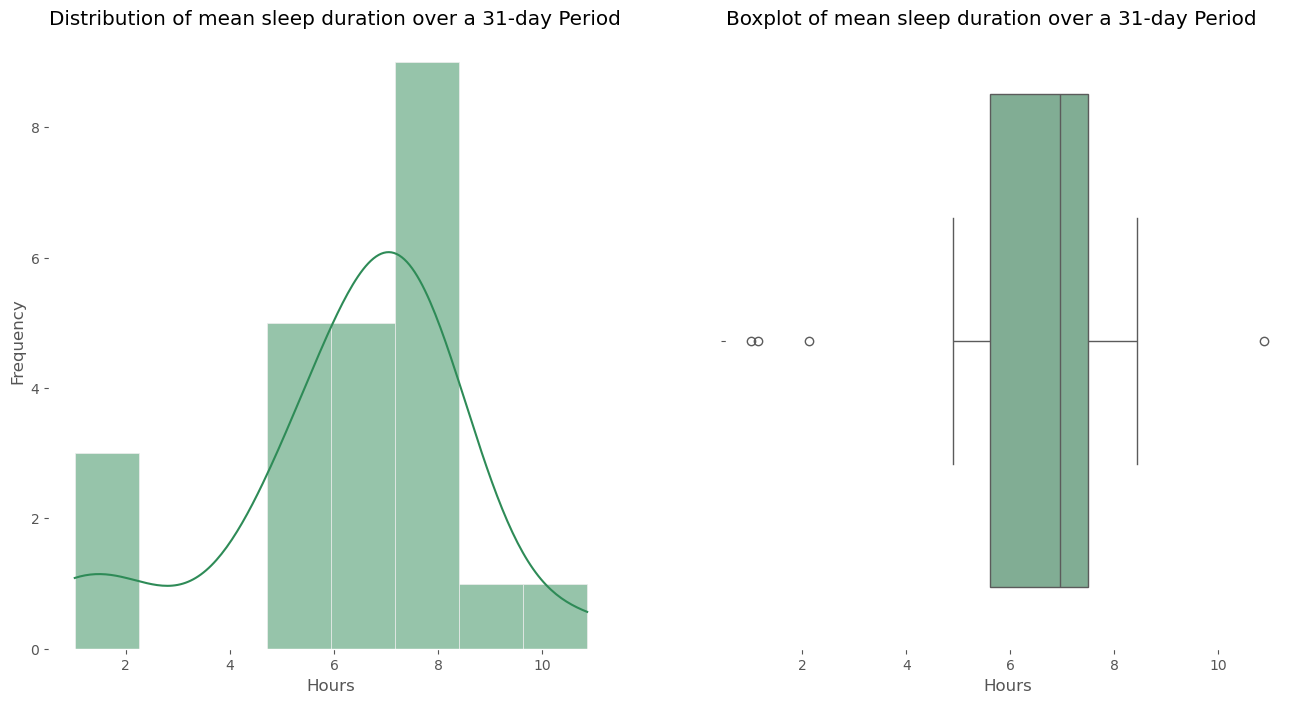

In [540]:
# Plotting participants' daily step count without regard for the identity of the participants. Each count is the number of steps for each day
fig, ax = plt.subplots(1, 2, figsize=(16,8))
sns.histplot(data=sleep_long, x='sleep_hrs', color=sns.light_palette("seagreen")[-1], kde=True, ax=ax[0])
sns.boxplot(data=sleep_long, x='sleep_hrs', color=sns.light_palette("seagreen")[-3], ax=ax[1])

# Setting axes labels
ax[0].set_xlabel('Hours')
ax[0].set_ylabel('Frequency')
ax[0].set_title('Distribution of mean sleep duration over a 31-day Period', loc='left')
ax[1].set_xlabel('Hours')
ax[1].set_title('Boxplot of mean sleep duration over a 31-day Period', loc='left')
ax[0].set_facecolor('white')
ax[1].set_facecolor('white')

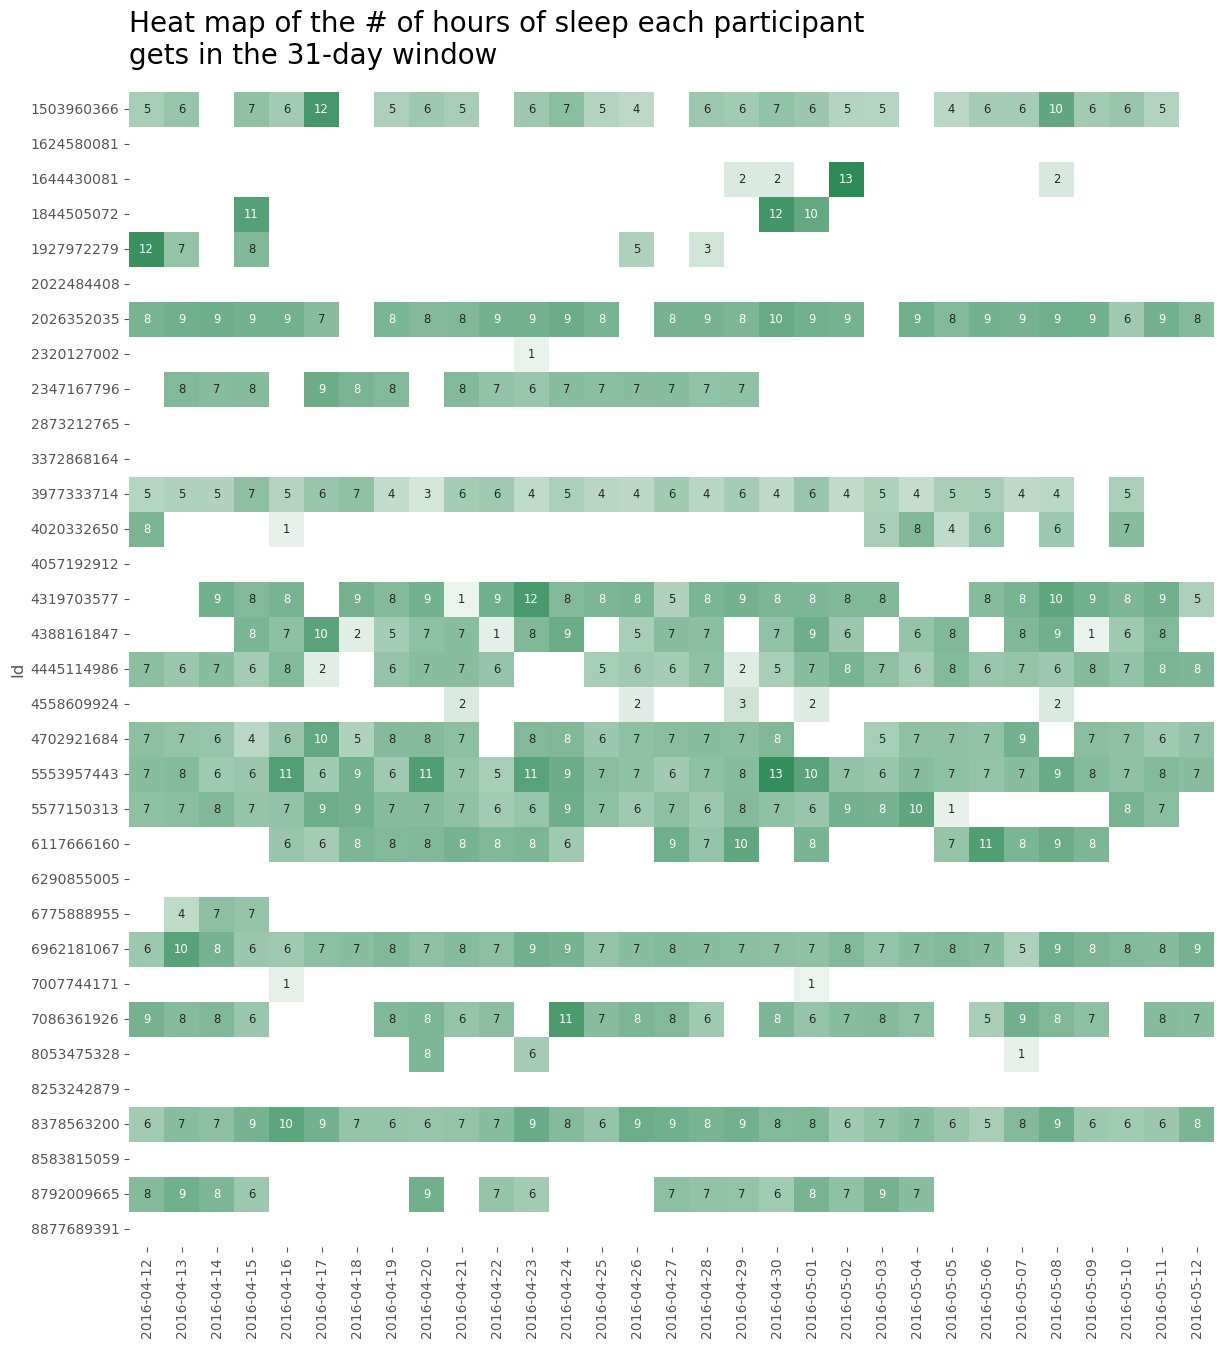

In [499]:
# Setting the size of the visualisation
plt.subplots(figsize=(15,15))

# Using a green sequential palette to visualise sleep. The more intense the colour, the greater the number of hours of sleep
seagreen_palette = sns.light_palette("seagreen", as_cmap=True)

# Creating labels for the heatmap
labels = sleep_pivot.map(lambda x: f'{x:.0f}')

# Creating the visualisation
g = sns.heatmap(sleep_pivot, square=True, cmap=seagreen_palette, 
            annot=labels, annot_kws={'size':'small', 'alpha':1}, 
            fmt='', cbar=False)

g.axes.set_title('Heat map of the # of hours of sleep each participant \ngets in the 31-day window', fontsize=20, loc='left', pad=20) # type: ignore
g.axes.set_facecolor('white')  # type: ignore


##### Q5: Who gets more sleep, those who track their sleep information, or those who dont?

<ins>Summary of Findings</ins>
- It would seem that people who tracked their sleep has a higher average sleep duration. I.e. People who get more sleep tracked their sleep cycles more than those who had gotten less sleep
- We should be wary about making a casual link between tracking sleep and the number of hours of sleep. We <ins>__cannot__</ins> infer that tracking sleep results in more sleep, or vice versa.


In [509]:
# Finding the mean sleep duration for each participant
mean_sleep = sleep_pivot.mean(axis=1)

# If the participant has at least 15 sleep records, s/he is labelled as a tracker, otherwise s/he is labelled as a non-tracker
tracker_label = num_of_tracked_sleep_days['TotalSleepRecords'].apply(lambda x: 'tracker' if x > 15 else 'non-tracker')

# combine the two series together
mean_sleep_with_tracker_label = mean_sleep.to_frame().merge(tracker_label, how='inner', left_index=True, right_index=True)

# renaming the columns
mean_sleep_with_tracker_label.columns = ['mean_sleep_hrs', 'label']

mean_sleep_with_tracker_label

,mean_sleep_hrs,label
Id,,
1503960366,6.004667,tracker
1624580081,NaN,non-tracker
1644430081,4.900000,non-tracker
1844505072,10.866667,non-tracker
1927972279,6.950000,non-tracker
...,...,...
8253242879,NaN,non-tracker
8378563200,7.418817,tracker
8583815059,NaN,non-tracker


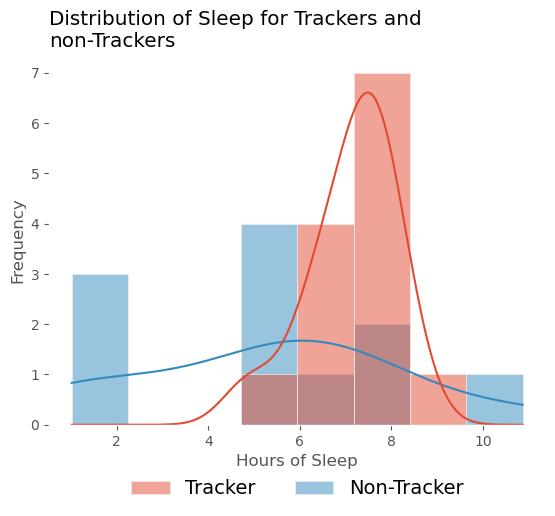

In [510]:
g = sns.histplot(data=mean_sleep_with_tracker_label, x='mean_sleep_hrs', hue='label', kde=True)

g.axes.set_facecolor('white') # type: ignore
g.axes.set_title('Distribution of Sleep for Trackers and \nnon-Trackers', loc='left') # type: ignore
g.axes.set_xlabel('Hours of Sleep') # type: ignore
g.axes.set_ylabel('Frequency') # type: ignore

# Recreating the legend. The main problem is that ax1.get_legend_handles_labels() returns empty lists.
legend = g.axes.get_legend() # type: ignore
handles = legend.legend_handles

# You have to remove the existing legend and recreate the legend
legend.remove()

# Re-creating the legend
g.axes.legend(handles, ['Tracker', 'Non-Tracker'], title='', bbox_to_anchor=(0.5, -0.1), loc='upper center', frameon = False, ncol=2, fontsize=14) # type: ignore

In [512]:
mean_sleep_tracker = mean_sleep_with_tracker_label.query('label == "tracker"')['mean_sleep_hrs'].mean()
mean_sleep_non_tracker = mean_sleep_with_tracker_label.query('label == "non-tracker"')['mean_sleep_hrs'].mean()
print(mean_sleep_tracker, mean_sleep_non_tracker)

7.128339643182551 5.300921717171717


Remarks and Findings:
- The criteria for differentiating sleep trackers and non-sleep trackers is arbitrary. 15 was chosen as it was the halfway point between 0 and 31.
- Based on the histogram and mean sleep hours, it would seem that people who tracked their sleep has a higher average sleep duration

##### Q6: How long do participants sleep? Investigating the distribution of sleep duration.
- Here we plot a histogram of all daily sleep duration. This allows us to compute the mean sleep duration for every one for every day

<ins>Summary of Findings</ins>
- The mean sleep duration is 7.0 hours, median is 7.2 hours, making this a right-skewed graph
- People generally sleep between 6 - 8 hours

In [550]:
# Converting the pivot table, which is a wide data format, into a long data format. 
sleep_long = sleep_pivot.reset_index().melt(id_vars=['Id'], var_name='day', value_name='sleep_hours')
# sleep_long

In [551]:
# Obtaining the summary statstic for sleep duration
sleep_long['sleep_hours'].describe()

count    410.000000
mean       6.986220
std        1.977265
min        0.966667
25%        6.016667
50%        7.208333
75%        8.166667
max       13.266667
Name: sleep_hours, dtype: float64

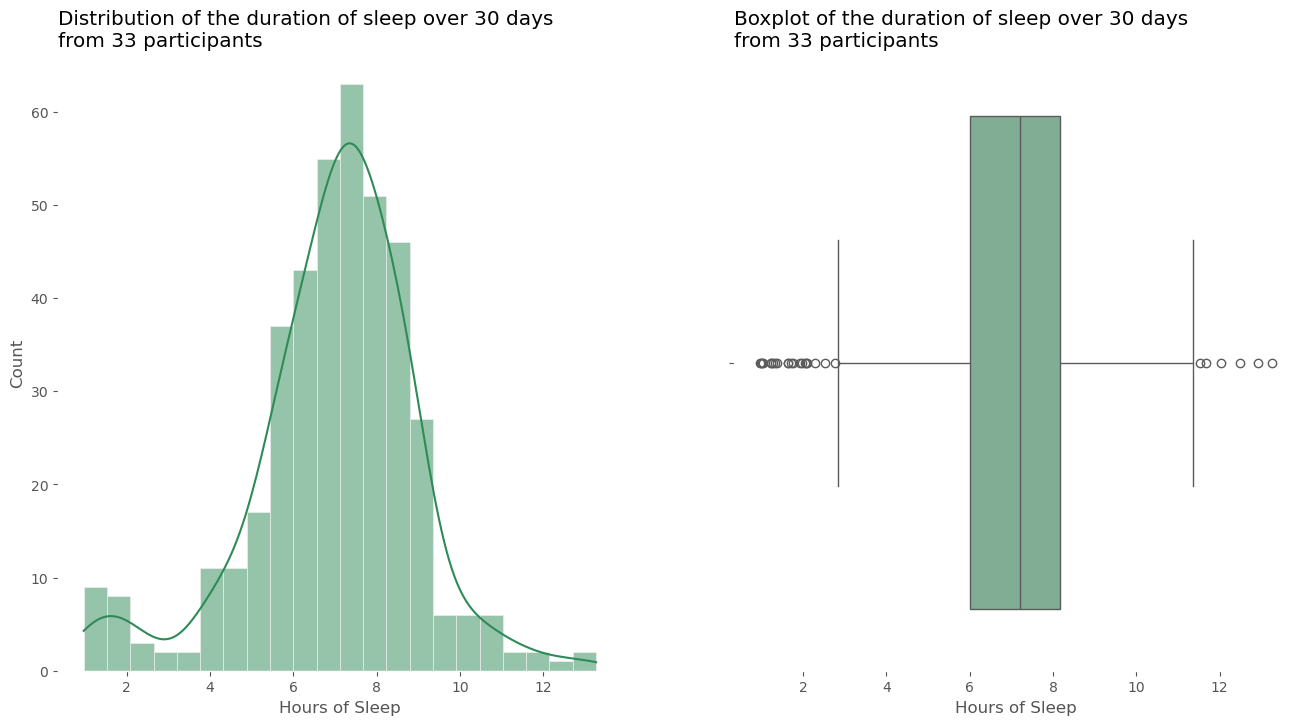

In [549]:
# Drawing the figure
fig, ax = plt.subplots(1, 2, figsize=(16,8))

sns.histplot(data=sleep_long, x='sleep_hours', color=sns.light_palette("seagreen")[-1], kde=True, ax=ax[0])
sns.boxplot(data=sleep_long, x='sleep_hours', color=sns.light_palette("seagreen")[-3], ax=ax[1])

# Setting axes labels
ax[0].set_xlabel('Hours of Sleep')
ax[0].set_ylabel('Count')
ax[0].set_title('Distribution of the duration of sleep over 30 days \nfrom 33 participants', loc='left')
ax[1].set_xlabel('Hours of Sleep')
ax[1].set_title('Boxplot of the duration of sleep over 30 days \nfrom 33 participants', loc='left')
ax[0].set_facecolor('white')
ax[1].set_facecolor('white')

Remarks and Findings
- Sleep data indicates that 50% of sleep have duration between 6-8 hours

##### Q7: Investigation into the Time Taken to Fall Asleep
- This investigates the time taken to fall asleep. The average person takes between [15 - 20 minutes][sleep_foundation] to fall asleep. Anything longer or shorter might suggest underlying issues that require medical intervention
- Tracking the time taken to fall asleep is therefore important, and the bellabeat app can suggest strategies for people to cope with longer-than-usual sleep transition times, e.g. sleep hygiene, regular sleep schdules etc.

<ins>Summary of Findings</ins>
- the mean time taken to fall asleep is 39 minutes, and the median is 25 minutes. this is an extremely right skewed graph.
- There are many outliers, some taking more than 200 minutes to fall asleep. Further investigation is needed to check if this is indeed an legitimate result, an error in recording.

[sleep_foundation]: https://www.sleepfoundation.org/sleep-faqs/how-long-should-it-take-to-fall-asleep



In [552]:
df['transition_into_sleep'] = df.loc[:, 'TotalTimeInBed'].subtract(df.loc[:, 'TotalMinutesAsleep'])

In [555]:
df['transition_into_sleep'].describe()

count    410.000000
mean      39.309756
std       46.710932
min        0.000000
25%       17.000000
50%       25.500000
75%       40.000000
max      371.000000
Name: transition_into_sleep, dtype: float64

<Axes: xlabel='transition_into_sleep', ylabel='Count'>

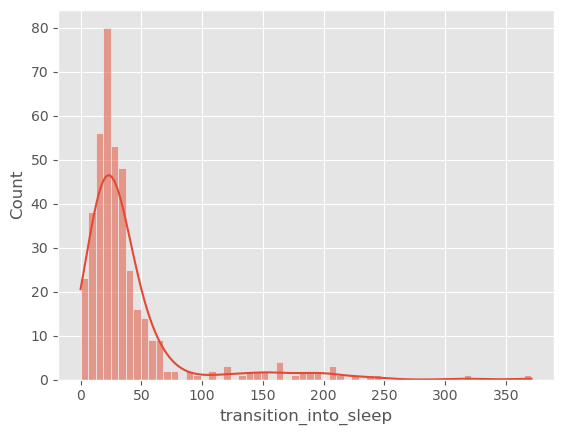

In [554]:
# Drawing the figure
fig, ax = plt.subplots(1, 2, figsize=(16,8))

sns.histplot(data=sleep_long, x='sleep_hours', color=sns.light_palette("seagreen")[-1], kde=True, ax=ax[0])
sns.boxplot(data=sleep_long, x='sleep_hours', color=sns.light_palette("seagreen")[-3], ax=ax[1])

# Setting axes labels
ax[0].set_xlabel('Hours of Sleep')
ax[0].set_ylabel('Count')
ax[0].set_title('Distribution of the duration of sleep over 30 days \nfrom 33 participants', loc='left')
ax[1].set_xlabel('Hours of Sleep')
ax[1].set_title('Boxplot of the duration of sleep over 30 days \nfrom 33 participants', loc='left')
ax[0].set_facecolor('white')
ax[1].set_facecolor('white')

#### Distance

##### Q8 How many people use their smart devices to track distance walked? How many people use their wearables to track the __distance__ walked each day?
- __Caution__: Some distance values are recorded with 2 decimal places while others have 5-6 trailing decimals places. Unless there is a functionality within the wearable that allows participants to manually enter the data, we will need to suspect data credibility issues in this column.
- Everyone has at least one day of distance data in the dataset. This is not surprising because this is automatically tracked when you put on your smart device. The mean number of days tracked is 28 days while the median is 31 days, making this a left-skewed graph.

In [566]:
# pivoting the dataset on Id, Date, and Distance
distance_pivot = df.pivot_table(index=['Id'], columns=['ActivityDate'], values=['TotalDistance'])
# distance_pivot

TotalDistance                                              \
ActivityDate    2016-04-12 2016-04-13 2016-04-14 2016-04-15 2016-04-16   
Id                                                                       
1503960366            8.50       6.97       6.74       6.28   8.160000   
1624580081            5.31       4.55       5.92       0.98   3.490000   
1644430081            7.77       5.82       8.02       3.83  11.120000   
1844505072            4.43       3.26       5.25       2.54   2.260000   
1927972279            0.47       0.25       1.50       0.68   0.000000   
...                    ...        ...        ...        ...        ...   
8253242879            7.16       6.10       3.46       1.77   6.140000   
8378563200            6.05       9.82      10.56      11.47   8.890000   
8583815059            3.91       4.35       2.45       2.68   4.150000   
8792009665            1.64       0.84       0.78       1.59   0.160000   
8877689391           20.40       9.58      18.98       7.17  25.290001   

                                                                     \
ActivityDate 2016-04-17 2016-04-18 2016-04-19 2016-04-20 2016-04-21   
Id                                                                    
1503960366         6.48       8.59       9.88   6.680000   6.340000   
1624580081         4.06       7.41       1.90   3.230000   4.130000   
1644430081         6.37       5.19       8.18   1.770000   0.890000   
1844505072         2.99       3.04       0.13   0.010000   5.320000   
1927972279         0.00       0.17       0.00   0.000000   0.000000   
...                 ...        ...        ...        ...        ...   
8253242879         7.91       3.48       2.78   4.270000   8.560000   
8378563200         1.69      10.81      10.36   7.440000  12.010000   
8583815059         2.35       3.01       4.44   4.110000   6.660000   
8792009665         0.00       0.00       0.00   2.010000   0.090000   
8877689391         8.87       8.67      17.40  18.110001  17.620001   

                                                                     \
ActivityDate 2016-04-22 2016-04-23 2016-04-24 2016-04-25 2016-04-26   
Id                                                                    
1503960366     8.130000       9.04       6.41       9.80       8.79   
1624580081     2.620000       5.55       3.95       4.22       1.84   
1644430081     2.670000       4.83       2.41       2.60       7.21   
1844505072     3.550000       2.36       0.00       0.00       0.00   
1927972279     0.100000       2.04       1.45       0.11       2.60   
...                 ...        ...        ...        ...        ...   
8253242879     1.870000       6.26       7.13       4.51       3.04   
8378563200     9.670000       4.53       2.94       9.84      12.85   
8583815059     6.780000       7.35       6.46       3.51       8.19   
8792009665     2.600000       3.36       0.26       0.00       0.85   
8877689391    16.309999       7.43      15.74       8.74       8.43   

                                                                     \
ActivityDate 2016-04-27 2016-04-28 2016-04-29 2016-04-30 2016-05-01   
Id                                                                    
1503960366        12.21       8.53       7.15   9.250000   6.810000   
1624580081         5.44       1.79       1.55   4.300000  28.030001   
1644430081         2.20       6.84       2.31  13.240000   4.460000   
1844505072         0.00       4.57       3.25   2.670000   1.700000   
1927972279         0.00       1.16       0.00   0.000000   1.870000   
...                 ...        ...        ...        ...        ...   
8253242879         8.18       1.80       4.26   0.000000        NaN   
8378563200         5.84       4.30       4.90   2.340000   9.060000   
8583815059         9.73       4.82      11.83   7.870000   3.520000   
8792009665         1.13       3.94       5.35   4.590000   1.040000   
8877689391        20.65      11.30       7.39  26.719999   8.32

In [592]:
# Creating an array suitable for plotting distributions
distance_forhist = distance_pivot.notna().sum(axis=1).to_frame()
distance_forhist.rename(columns={0: 'days'}, inplace=True)
# distance_forhist

In [593]:
distance_forhist.describe()

,days
count,33.000000
mean,28.484848
std,5.657524
min,4.000000
25%,29.000000
50%,31.000000
75%,31.000000
max,31.000000


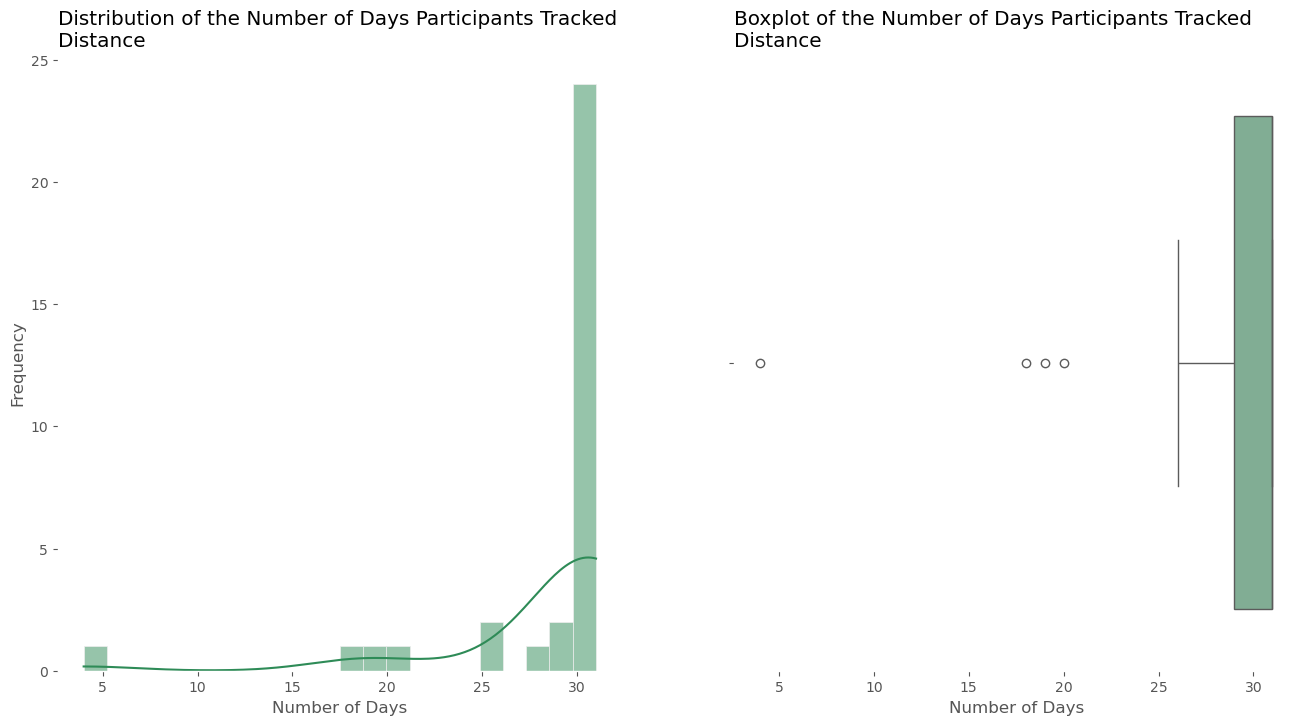

In [594]:
fig, ax = plt.subplots(1, 2, figsize=(16,8))
sns.histplot(data=distance_forhist, x='days', color=sns.light_palette("seagreen")[-1], kde=True, ax=ax[0])
sns.boxplot(data=distance_forhist, x='days', color=sns.light_palette("seagreen")[-3], ax=ax[1])

# Setting axes labels
ax[0].set_xlabel('Number of Days')
ax[0].set_ylabel('Frequency')
ax[0].set_title('Distribution of the Number of Days Participants Tracked \nDistance', loc='left')
ax[1].set_xlabel('Number of Days')
ax[1].set_title('Boxplot of the Number of Days Participants Tracked \nDistance', loc='left')
ax[0].set_facecolor('white')
ax[1].set_facecolor('white')

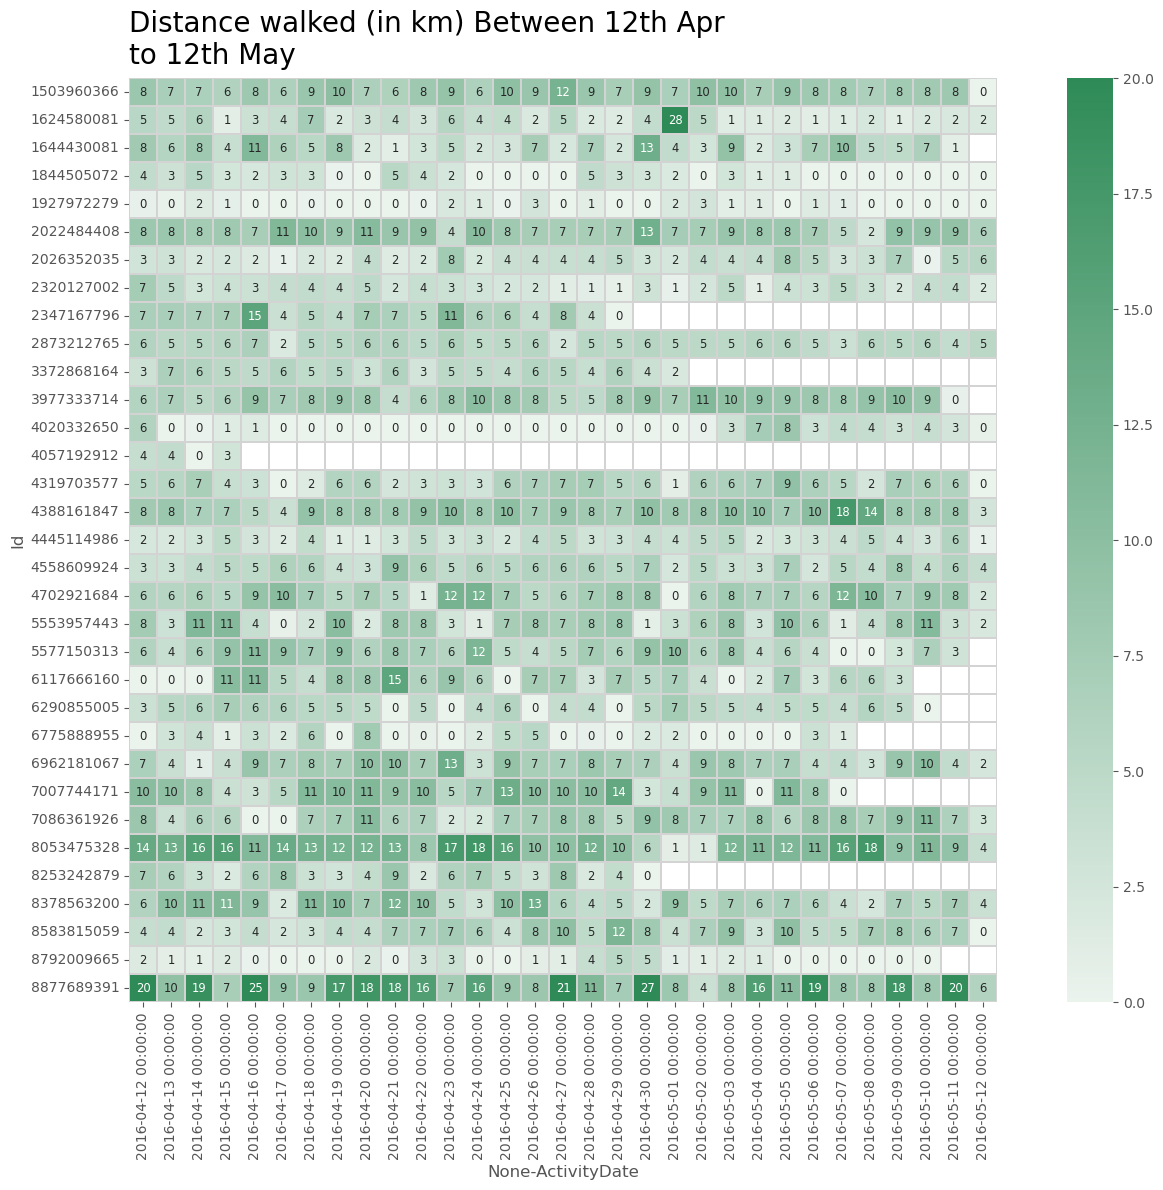

In [565]:
plt.subplots(figsize=(18,12))

# Using a green sequential palette to visualise sleep. The intense green i
seagreen_palette = sns.light_palette("seagreen", as_cmap=True)

# Creating labels for the heatmap
labels = distance_pivot.map(lambda x: f'{x:.0f}')

g = sns.heatmap(distance_pivot, square=True, 
                cmap=seagreen_palette, cbar=True,  # type: ignore
                vmin=0, vmax=20,
                linewidths=0.1, linecolor='lightgrey',
                annot=labels, annot_kws={'size':'small', 'alpha':1}, fmt='',
                xticklabels=steps.columns) # type: ignore

g.axes.set_title('Distance walked (in km) Between 12th Apr \nto 12th May',  # type: ignore
                 loc='left', fontsize=20, pad=10)
g.axes.set_facecolor('white') # type: ignore

##### Q9: If we take the average of distance travelled for each participant, What is the mean distance walked for the entire dataset?
<ins> Summary of Findings</ins>
- On average, particiapnts travelled 5.4km every day

In [601]:
# Creating an array suitable for plotting distributions
distance_km_forhist = distance_pivot.mean(axis=1).to_frame()
distance_km_forhist.rename(columns={0: 'km'}, inplace=True)
# distance_km_forhist

,km
Id,
1503960366,7.809677
1624580081,3.914839
1644430081,5.295333
1844505072,1.706129
1927972279,0.634516
...,...
8253242879,4.667368
8378563200,6.913548
8583815059,5.615484


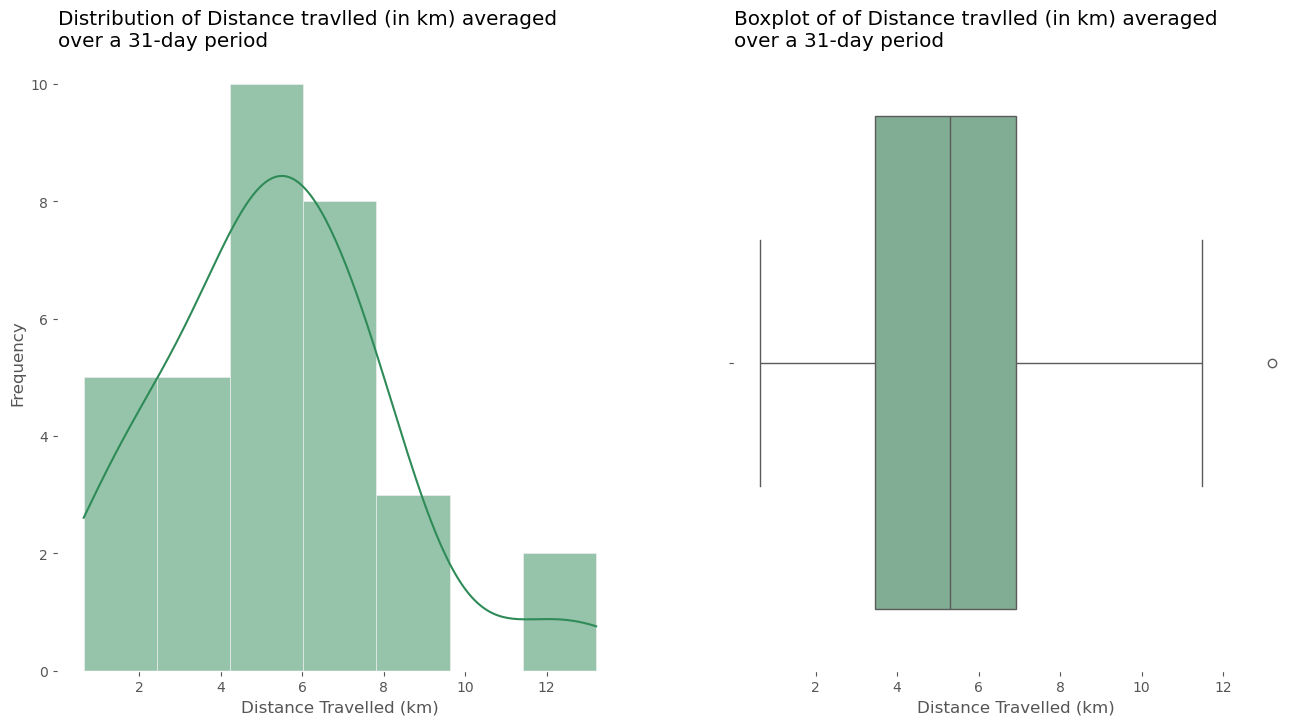

In [609]:
fig, ax = plt.subplots(1, 2, figsize=(16,8))
sns.histplot(data=distance_km_forhist, x='km', color=sns.light_palette("seagreen")[-1], kde=True, ax=ax[0])
sns.boxplot(data=distance_km_forhist, x='km', color=sns.light_palette("seagreen")[-3], ax=ax[1])

# Setting axes labels
ax[0].set_xlabel('Distance Travelled (km)')
ax[0].set_ylabel('Frequency')
ax[0].set_title('Distribution of Distance travlled (in km) averaged \nover a 31-day period', 
                loc='left')
ax[1].set_xlabel('Distance Travelled (km)')
ax[1].set_title('Boxplot of of Distance travlled (in km) averaged \nover a 31-day period', 
                loc='left')
ax[0].set_facecolor('white')
ax[1].set_facecolor('white')

#### Activities

##### Q3: How many people logged their activities?
- Notice that `LoggedActivitiesDistance` + `TrackerDistance` =/= `Total Distance`. so there is some double counting of distance between `TrackerDistance` and `LoggedActivitiesDistance` that we are not aware of. 
- Here, I will make the assumption that `TrackerDistance` is the distance that the weareable tracks in the background. For `LoggedActivitiesDistance` to be recorded, the wearer has to manually press a button on the wearable to track the distance.
- It is difficult to infer the difference between a value of a 0 and a null in the `LoggedActivitiesDistance` column
- The heatmap shows that a lot of people just do not log their activities.

In [ ]:
# Retrieve only 'LoggedActivitiesDistance'. We find that there are many zeros in the dataset.
df['LoggedActivitiesDistance']

0      0.0
1      0.0
2      0.0
3      0.0
4      0.0
      ... 
935    0.0
936    0.0
937    0.0
938    0.0
939    0.0
Name: LoggedActivitiesDistance, Length: 940, dtype: float64

In [ ]:
# This shows the rows where Logged Activities are more than 0
df[df['LoggedActivitiesDistance'] > 0]

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
668,6775888955,2016-04-26,7091,5.27,5.27,1.959596,3.48,0.87,0.73,0.00,42,30,47,1321,2584
689,6962181067,2016-04-21,11835,9.71,7.88,4.081692,3.99,2.10,3.51,0.11,53,27,214,708,2179
693,6962181067,2016-04-25,13239,9.27,9.08,2.785175,3.02,1.68,4.46,0.10,35,31,282,637,2194
707,6962181067,2016-05-09,12342,8.72,8.68,3.167822,3.90,1.18,3.65,0.00,43,21,231,607,2105
711,7007744171,2016-04-12,14172,10.29,9.48,4.869783,4.50,0.38,5.41,0.00,53,8,355,1024,2937
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
841,8378563200,2016-05-05,8567,6.79,6.79,2.253081,0.89,0.16,5.74,0.00,66,3,214,764,3783
842,8378563200,2016-05-06,7045,5.59,5.59,2.092147,1.55,0.25,3.78,0.00,74,5,166,831,3644
845,8378563200,2016-05-09,8382,6.65,6.65,2.092147,1.27,0.66,4.72,0.00,71,13,171,772,3721
846,8378563200,2016-05-10,6582,5.22,5.22,2.253081,0.66,0.64,3.92,0.00,63,13,152,840,3586


In [ ]:
# Making a pivot table to investigate how many people log their activities, and on which day peoplelog their activities
logged_activities = df.pivot_table(index=['Id'], columns=['ActivityDate'], values=['LoggedActivitiesDistance'], aggfunc='sum')

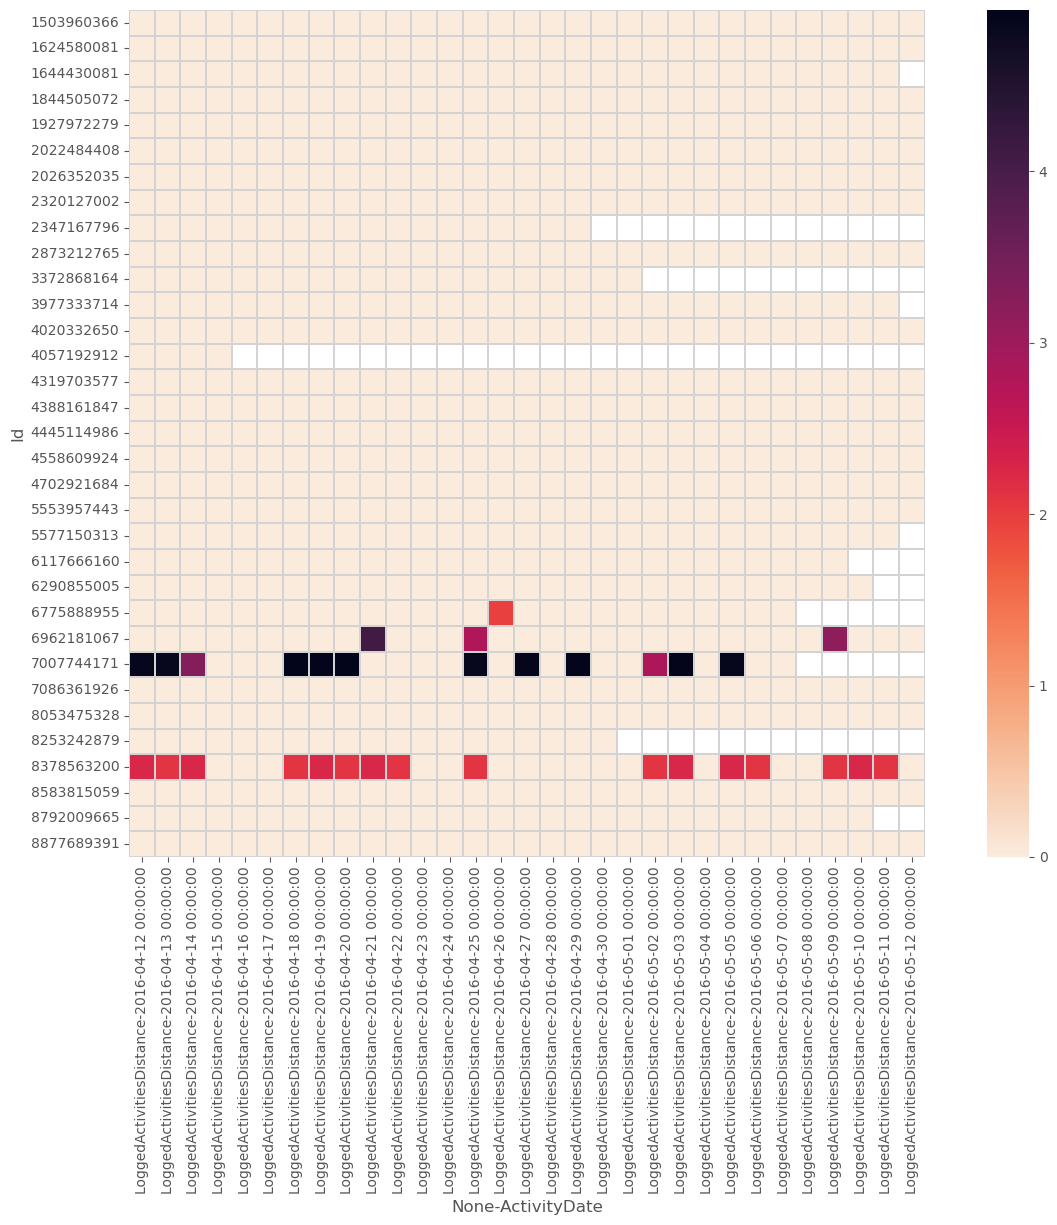

In [ ]:
# Visualising the above pivot table
plt.subplots(figsize=(16,11))
g = sns.heatmap(logged_activities, square=True, cmap='rocket_r', linewidths=0.1, linecolor='lightgrey')
g.axes.set_facecolor('white')


Findings:
- The cream coloured boxes represent values that are zero, while white-coloured boxes represent values that are null. It is unclear what the differences are. 
- Suffice to say the bulk of participants did not log their activities for the associated distances to be captured

##### Q4: How many people use their wearables to track their calories?
- Everyone in the dataset has used their weareables to track their calories.
- The usual suspects; users `2347167796, 3372868164, 4057192912, 8253242879` seemingly stopped using their weareables. These users have less than 21 days of information in the `Calories` column

In [ ]:
calories = df.pivot_table(index=['Id'], columns=['ActivityDate'], values=['Calories'])

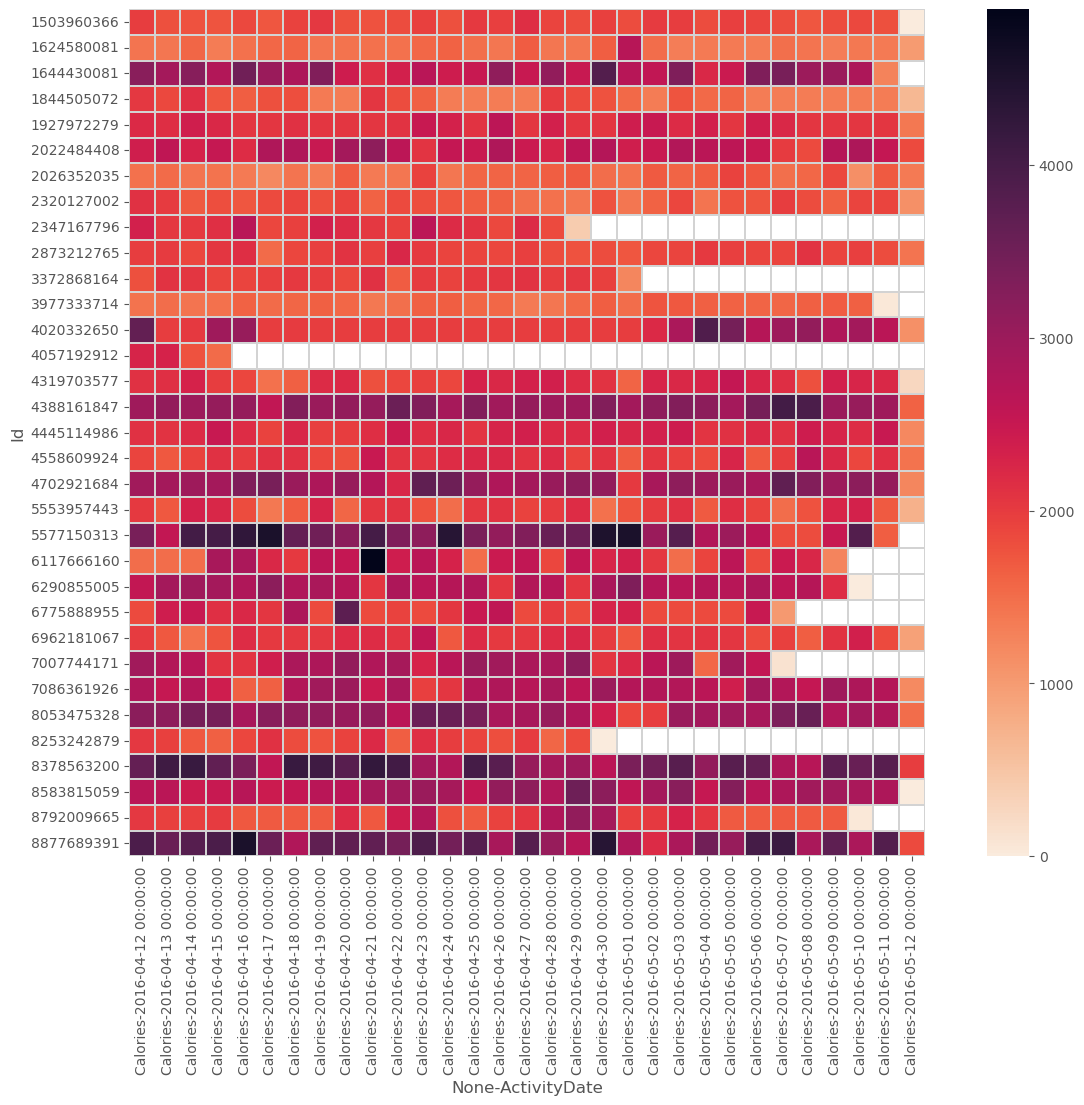

In [ ]:
plt.subplots(figsize=(16,11))
g = sns.heatmap(calories, square=True, linewidths=0.2, linecolor='lightgrey', cmap='rocket_r')
g.axes.set_facecolor('white')

In [ ]:
# Finding the participants that abruptly stopped counting their calories

tracked_num = df.groupby('Id')[['Calories']].agg('count')
tracked_num[tracked_num['Calories'] < 21].index.values

array([2347167796, 3372868164, 4057192912, 8253242879])

The usual participants 2347167796, 3372868164, 4057192912, 8253242879 stopped tracking calories

1503960366
1624580081
1644430081
1844505072
1927972279


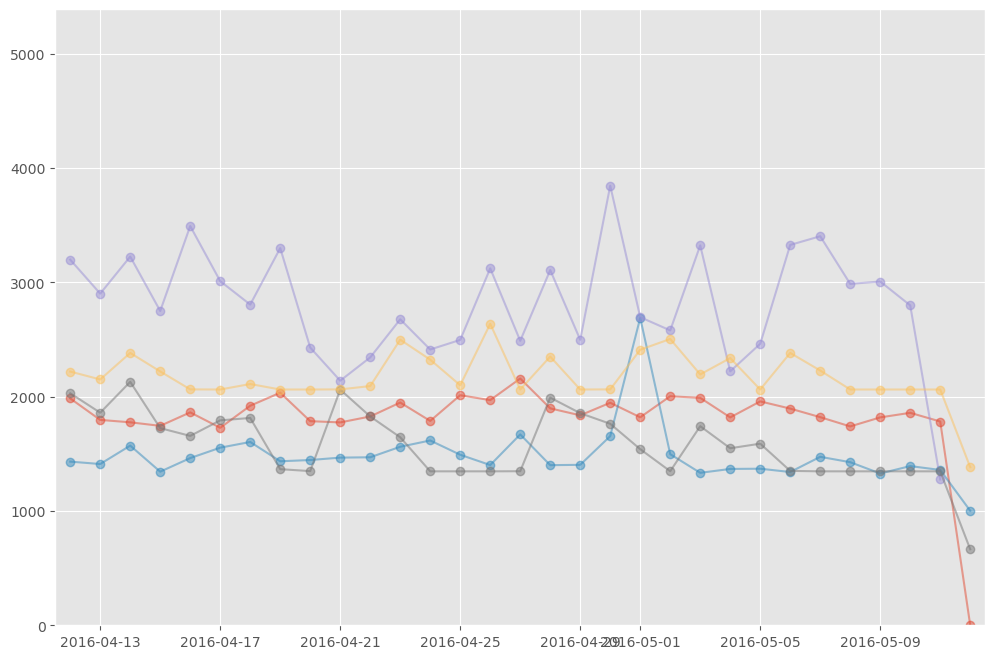

In [ ]:
# here we are plotting the calorie intake of user(s) over a 30-day period. This is controlled by line 5
fig, ax = plt.subplots(figsize=(12,8))
fig.set_size_inches((12,8))

for i in df['Id'].unique()[0:5]: # change the number to plot more or less people
    print(i)
    data = df.query('Id == @i').drop('Id', axis=1).set_index('ActivityDate')

    x = data.index
    y = data.Calories
    ax.plot(x,y, 'o-', alpha = 0.5)

    ax.set_xlim(df['ActivityDate'].min()-datetime.timedelta(days=0.5), df['ActivityDate'].max()+datetime.timedelta(days=0.5))
    ax.set_ylim(df['Calories'].min(), df['Calories'].max()*1.1)

##### Q5: Exploring the Distances Columns
- Here, I am trying to understand the relationship between `'VeryActiveDistance', 'ModeratelyActiveDistance', 'LightActiveDistance', 'SedentaryActiveDistance'`, `TotalDistance`, and `TrackerDistance`.
- The difference between `TotalDistance` and `'VeryActiveDistance', 'ModeratelyActiveDistance', 'LightActiveDistance', 'SedentaryActiveDistance'` is almost zero for most, but there are large occasional discrepancies in distances of up to 9km in some instances.
- Wihtout further information to inform us about how these distances are recorded and calculated, it is hard to derive further information with these columns.
- We should retain Q2's conclusion that distance data can be found in many of the participants' tracking data

<Axes: >

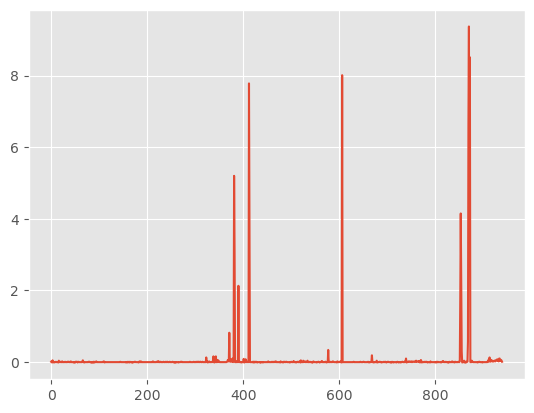

In [ ]:
(df['TotalDistance'] - df.loc[:, ['VeryActiveDistance', 'ModeratelyActiveDistance', 'LightActiveDistance', 'SedentaryActiveDistance']].sum(axis=1)).plot()

In [ ]:
df

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
0,1503960366,2016-04-12,13162,8.500000,8.500000,0.0,1.88,0.55,6.06,0.00,25,13,328,728,1985
1,1503960366,2016-04-13,10735,6.970000,6.970000,0.0,1.57,0.69,4.71,0.00,21,19,217,776,1797
2,1503960366,2016-04-14,10460,6.740000,6.740000,0.0,2.44,0.40,3.91,0.00,30,11,181,1218,1776
3,1503960366,2016-04-15,9762,6.280000,6.280000,0.0,2.14,1.26,2.83,0.00,29,34,209,726,1745
4,1503960366,2016-04-16,12669,8.160000,8.160000,0.0,2.71,0.41,5.04,0.00,36,10,221,773,1863
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
935,8877689391,2016-05-08,10686,8.110000,8.110000,0.0,1.08,0.20,6.80,0.00,17,4,245,1174,2847
936,8877689391,2016-05-09,20226,18.250000,18.250000,0.0,11.10,0.80,6.24,0.05,73,19,217,1131,3710
937,8877689391,2016-05-10,10733,8.150000,8.150000,0.0,1.35,0.46,6.28,0.00,18,11,224,1187,2832
938,8877689391,2016-05-11,21420,19.559999,19.559999,0.0,13.22,0.41,5.89,0.00,88,12,213,1127,3832


### (3) ✖ Data exploration of the "heartrate_second_merged.csv" dataset

Summary: This dataset is quite incomplete, having less than half (14 out of 33) represented in this dataset. Furthermore, recordings were sporadic, and the frequency of collection differed from person to person. While the heart rate/ pulse rate is a useful indicator for the overall cardiac health, the collection of heart/pulse rate data is plagued with issues, such as (i) the lack of regularity in the colection of information, (ii) the lack of reliability in the technology used in the collection of data, and (iii) variance of quality of data which is dependent on how data is collected, with (i) clearly evident in this dataset. It is important, therefore, to understand that data relating to heart/pulse rate has interpretation of the wider lens of existing reliability issues.

One recommendation here is to work with the hardware team to improve the reliability of the devices

In [ ]:
chosen_file = filenames[3]
print(chosen_file)
df = pd.read_csv(chosen_file, parse_dates=['Time'])

./dataset/heartrate_seconds_merged.csv


#### (3) Check for duplicates and nulls

In [ ]:
df.isnull().sum()

Id       0
Time     0
Value    0
dtype: int64

In [ ]:
df.duplicated().sum()

0

- There are ~2.5 million records

In [ ]:
f'{df.shape[0]:,}, {df.shape[1]:,}'

'2,483,658, 3'

#### (3) Exploratory Data Analysis

Checking the number of records logged each day for each participant

In [ ]:
# Counting the number of records by day for each participant

heartrate_5sec = df.groupby(by=['Id', pd.Grouper(key='Time', freq='D')])[['Value']].agg('count').reset_index()
# heartrate_5sec

In [ ]:
# Pivoting the data, and visualising it in a heatmap

heartrate_5sec_pivot = heartrate_5sec.pivot_table(index=['Id'], columns=['Time'], values=['Value'])
heartrate_5sec_pivot

Value                                                         \
Time       2016-04-12 2016-04-13 2016-04-14 2016-04-15 2016-04-16 2016-04-17   
Id                                                                             
2022484408     4836.0     5332.0     5560.0     5302.0     3143.0     4948.0   
2026352035        NaN        NaN        NaN        NaN        NaN      192.0   
2347167796     6753.0     9268.0     9153.0     9557.0     9035.0     8990.0   
4020332650    33963.0        NaN     1448.0    10947.0     8523.0       69.0   
4388161847        NaN     8208.0     7392.0     9205.0     8970.0     8550.0   
4558609924     5973.0     2643.0     5331.0     8102.0     6881.0     6141.0   
5553957443     8370.0     8051.0     9922.0     9135.0     8238.0     1437.0   
5577150313     8685.0     3829.0     9806.0    17001.0    29330.0     8950.0   
6117666160        NaN        NaN        NaN     5443.0     9688.0     5824.0   
6775888955        NaN     4371.0     6099.0     3455.0      589.0      469.0   
6962181067     9196.0     8266.0     8089.0     8355.0     9880.0     8265.0   
7007744171     5506.0     5936.0     5982.0     4249.0     5640.0     5369.0   
8792009665     7587.0     8044.0     7461.0     3605.0        NaN        NaN   
8877689391     8280.0     8577.0     8096.0     9743.0     8431.0     8071.0   

                                                                              \
Time       2016-04-18 2016-04-19 2016-04-20 2016-04-21 2016-04-22 2016-04-23   
Id                                                                             
2022484408     5589.0     4500.0     6040.0     5544.0     5636.0     4178.0   
2026352035        NaN        NaN        NaN        NaN        NaN        NaN   
2347167796     9339.0     7824.0     7156.0     9289.0     9172.0     9543.0   
4020332650        NaN        NaN        NaN        NaN        NaN        NaN   
4388161847     8051.0     9274.0     9216.0     7907.0     7298.0     9326.0   
4558609924     6219.0     4438.0     5135.0     7867.0     6277.0     6342.0   
5553957443     7963.0    10572.0     8239.0     8951.0     9088.0     8275.0   
5577150313     8629.0     8667.0     6535.0    10106.0     8361.0     8519.0   
6117666160     4125.0     9169.0     9182.0     7416.0     9012.0     9450.0   
6775888955     2549.0       26.0     4389.0        NaN      340.0        NaN   
6962181067     7963.0     8612.0     8884.0     9147.0     9065.0     9856.0   
7007744171     6137.0     5737.0     5886.0     5820.0     5825.0     3034.0   
8792009665        NaN        NaN     7765.0      184.0     8429.0     9095.0   
8877689391     6542.0     7877.0     7807.0     7582.0     7885.0     9225.0   

                                                                              \
Time       2016-04-24 2016-04-25 2016-04-26 2016-04-27 2016-04-28 2016-04-29   
Id                                                                             
2022484408     4209.0     3812.0     5586.0     4441.0     5561.0     4832.0   
2026352035        NaN      516.0        NaN        NaN        NaN        NaN   
2347167796     8832.0     9528.0     9023.0     8842.0     9015.0     2364.0   
4020332650        NaN        NaN        NaN        NaN        NaN        NaN   
4388161847     8663.0     7759.0     9229.0     9351.0     7786.0     7489.0   
4558609924     6533.0     6750.0     7409.0     6494.0     7678.0     6943.0   
5553957443     7857.0     9165.0     8923.0     8705.0     9114.0    11959.0   
5577150313     8338.0     8877.0     8764.0     8756.0     9062.0     8712.0   
6117666160     5331.0        NaN     6372.0     9172.0     8044.0     9180.0   
6775888955      347.0     1805.0     1651.0        NaN      309.0       19.0   
6962181067     8643.0     9093.0     8917.0     8595.0     8928.0     9101.0   
7007744171     4138.0     6193.0     7129.0     5761.0     6310.0     6555.0   
8792009665      673.0        NaN     5348.0     8406.0     9374.0     8907.0   
8877689391    

In [ ]:
# Here, i will assume that records marked with NA means that there are no heartrate recorded for that day.
check_mean = heartrate_5sec_pivot.fillna(0)

print(check_mean.mean().mean(), check_mean.max().max(), check_mean.min().min())
print(heartrate_5sec_pivot.mean().mean(), heartrate_5sec_pivot.max().max(), heartrate_5sec_pivot.min().min())

5722.714285714286 37357.0 0.0
7478.069993089348 37357.0 19.0


NameError: name 'heartrate_5sec_pivot' is not defined

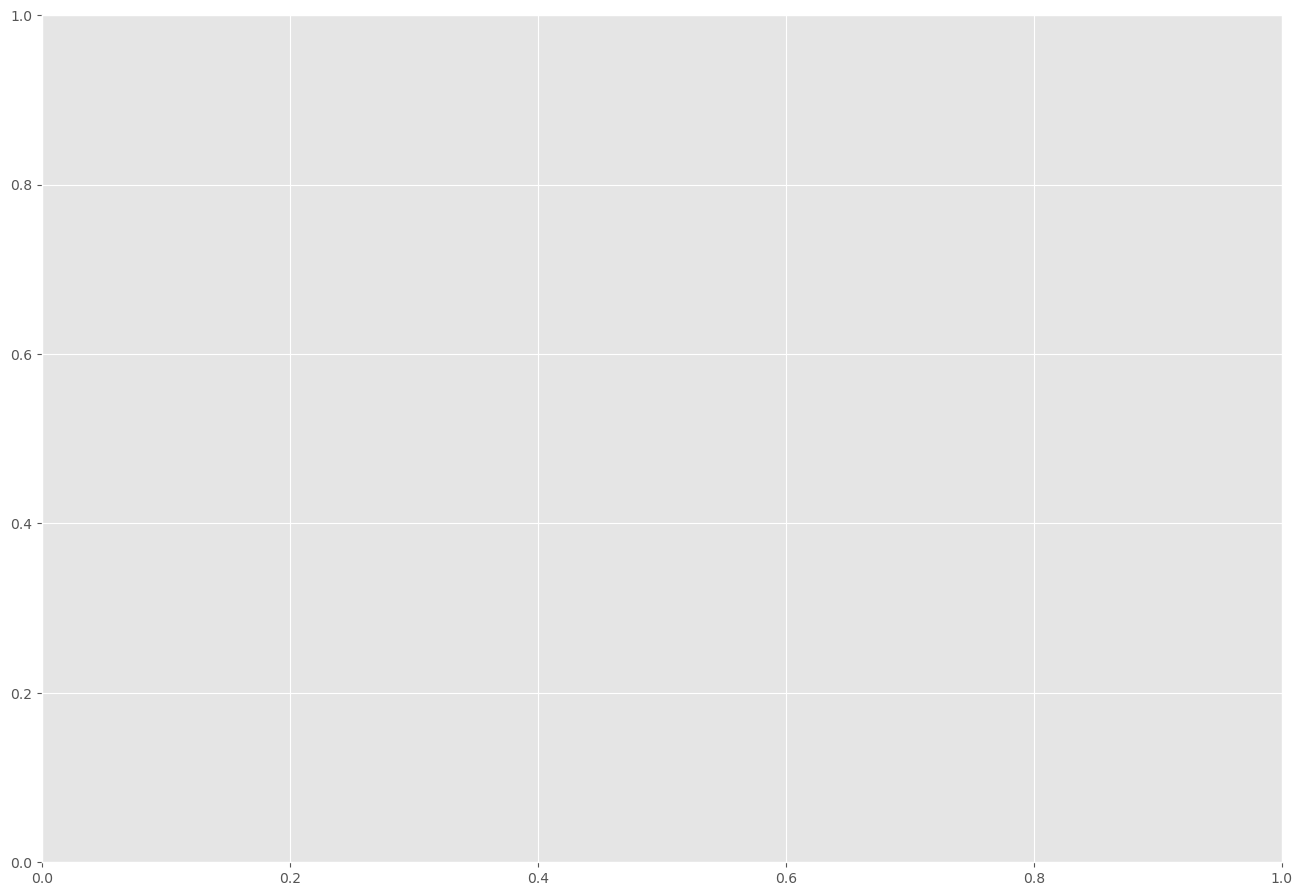

In [169]:
# Pivoting the data, and visualising it in a heatmap

plt.subplots(figsize=(16,11))
sns.heatmap(heartrate_5sec_pivot, cmap='rocket_r', square=True)

Remarks:
- There are 86400 seconds each day, and there are on average ~7.5k (nulls not replaced by zeros) records each day. This works out to be a measurement of heart rate 11-second intervals.
- We know that 2 months of data as well as 30 fitbit users are available in this dataset. However, only 1 month's worth of data and 14 participants were represented in this data. Further, heart rate data collection is irregular for everyone in this dataset.  There are days with higher number of records and days with lower number of records. The highest frequency-interval of heart rate collection is once every 3 seconds.
- In this [journal article][journal], the author acknowledges that use of heart rate has long been used as a clinical indicator of overall cardiac health. Heart rate recordings have historically been collected in discrete laboratory or medical environments that do not represent daily life.
- However, the accuracy of the data arising from wearables has always been an issue.

[journal]: https://www.nature.com/articles/s41746-020-0297-4

---

The following is a time series plot of at least one of the participants

2022484408
2026352035
2347167796


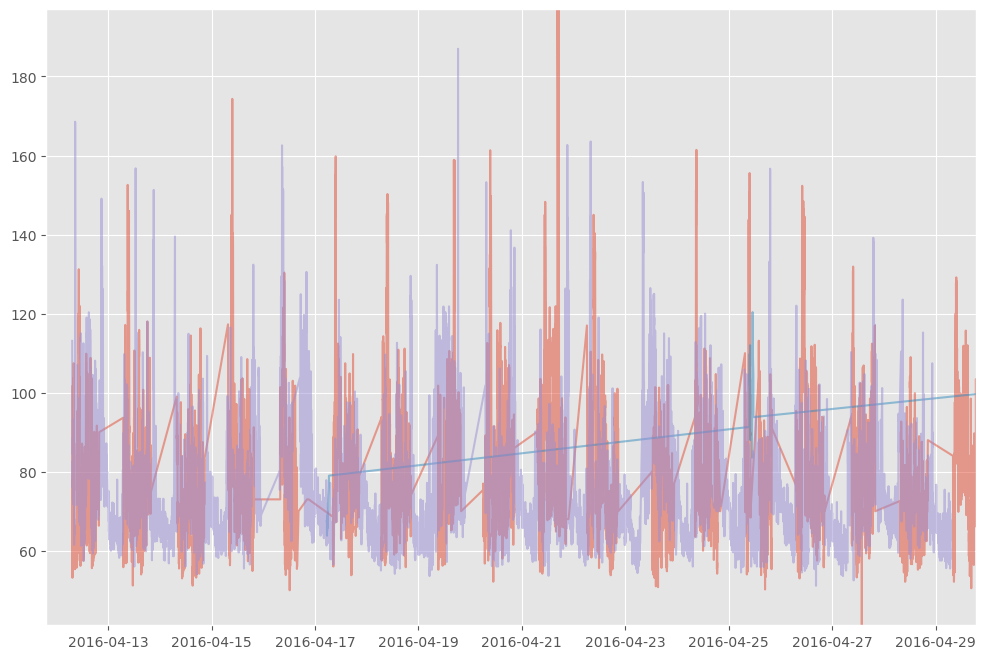

In [ ]:
# here we are plotting the heart rate of each user longitutinally at a 1-minute interval

heartrate_1min = df.groupby(by=['Id',pd.Grouper(key='Time', freq='1min')])[['Value']].agg('mean').reset_index()

fig, ax = plt.subplots()
fig.set_size_inches((12,8))

for i in heartrate_1min['Id'].unique()[0:3]:
    print(i)
    data = heartrate_1min.query('Id == @i').drop('Id', axis=1).set_index('Time')

    # The following is for one day
    # x = data[data.index.date == datetime.date(2016,4,12)].index
    # y = data[data.index.date == datetime.date(2016,4,12)].Value

    # Entire dataset
    x = data.index
    y = data.Value
    ax.plot(x,y, alpha = 0.5)

    ax.set_xlim(x.min()-datetime.timedelta(days=0.5), x.max()+datetime.timedelta(days=0.5))
    ax.set_ylim(y.min()-10, y.max()+10)